# Market-by-Market Money Influx Analysis
**Purpose:** Measure money entering each market per unit time to detect potential insider trading.

**Key signal:** Sustained large BUY flow *before* public information becomes available.

---

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from pathlib import Path
from datetime import datetime, timezone

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('ggplot')

plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 10, 'axes.labelsize': 9,
                     'xtick.labelsize': 7, 'ytick.labelsize': 7, 'legend.fontsize': 7})
EDA = Path('.')
C_BUY, C_SELL, C_NET = '#2ea043', '#cf222e', '#0075ca'

## Load data

In [2]:
PRICE_SCHEMA  = {'timestamp': pl.Int64, 'price': pl.Float64}
TRADES_SCHEMA = {'timestamp': pl.Int64, 'price': pl.Float64, 'size': pl.Float64}

markets = pl.read_csv(EDA / 'markets.csv')

def load_ph(slug):
    p = EDA / slug / 'price_history.csv'
    if not p.exists(): return pl.DataFrame({'timestamp': [], 'price': [], 'date': []}).cast({'timestamp': pl.Int64, 'price': pl.Float64})
    return (pl.read_csv(p, schema_overrides=PRICE_SCHEMA)
            .with_columns((pl.col('timestamp') * 1_000_000).cast(pl.Datetime('us')).alias('date')))

def load_tr(slug):
    p = EDA / slug / 'trades.csv'
    if not p.exists(): return None
    df = pl.read_csv(p, schema_overrides=TRADES_SCHEMA, ignore_errors=True)
    return df.with_columns((pl.col('timestamp') * 1_000_000).cast(pl.Datetime('us')).alias('date'))

print(f'Loaded {len(markets)} markets')

Loaded 20 markets


## Helper functions

In [3]:
fmt_usdc = mticker.FuncFormatter(lambda v, _: f'${abs(v)/1e6:.1f}M' if abs(v) >= 1e6
                                  else f'${abs(v)/1e3:.0f}K' if abs(v) >= 1e3 else f'${abs(v):.0f}')

def bucket_size(span_secs):
    """Choose a readable time bucket given the span of trade data."""
    if span_secs < 7_200:       return 600,      '10 min'
    if span_secs < 86_400:      return 3_600,    '1 hr'
    if span_secs < 7 * 86_400:  return 21_600,   '6 hr'
    return 86_400, '1 day'

def insider_score(buy_vol, sell_vol, max_bet, median_bet, span_days):
    """Qualitative insider signal score (0-10)."""
    score = 0
    total = buy_vol + sell_vol
    if total == 0: return 0, 'No data'
    # BUY dominance  (>80% BUY = +4)
    buy_ratio = buy_vol / total
    if buy_ratio > 0.95: score += 4
    elif buy_ratio > 0.85: score += 3
    elif buy_ratio > 0.70: score += 2
    elif buy_ratio > 0.55: score += 1
    # Whale concentration — max bet relative to median (+3)
    if median_bet > 0:
        whale_ratio = max_bet / median_bet
        if whale_ratio > 10000: score += 3
        elif whale_ratio > 1000: score += 2
        elif whale_ratio > 100: score += 1
    # Time spread — sustained accumulation over many days (+3)
    if span_days > 30: score += 3
    elif span_days > 7: score += 2
    elif span_days > 1: score += 1
    label = (['Low'] * 3 + ['Moderate'] * 3 + ['Elevated'] * 2 + ['High', 'Very High', 'Extreme'])[min(score, 10)]
    return score, label

print('Helpers ready')

Helpers ready


## Per-market analysis
Each panel shows one market. **Green = BUY flow, Red = SELL flow, Blue = net cumulative.**

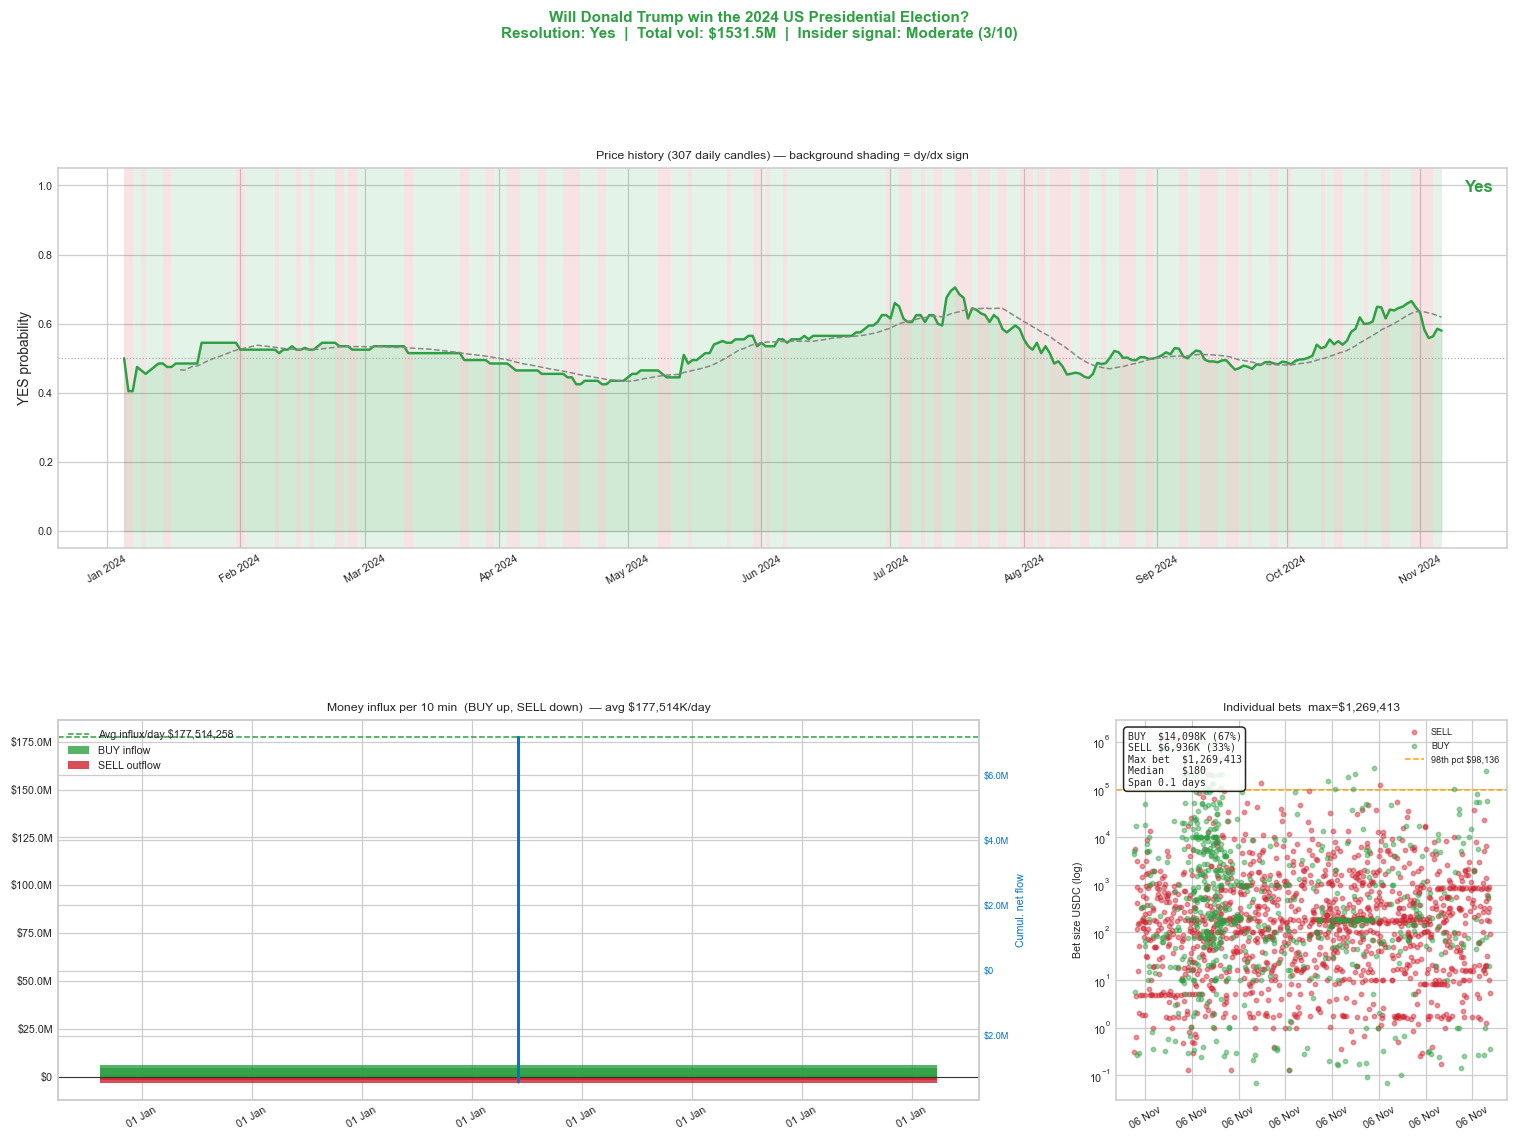

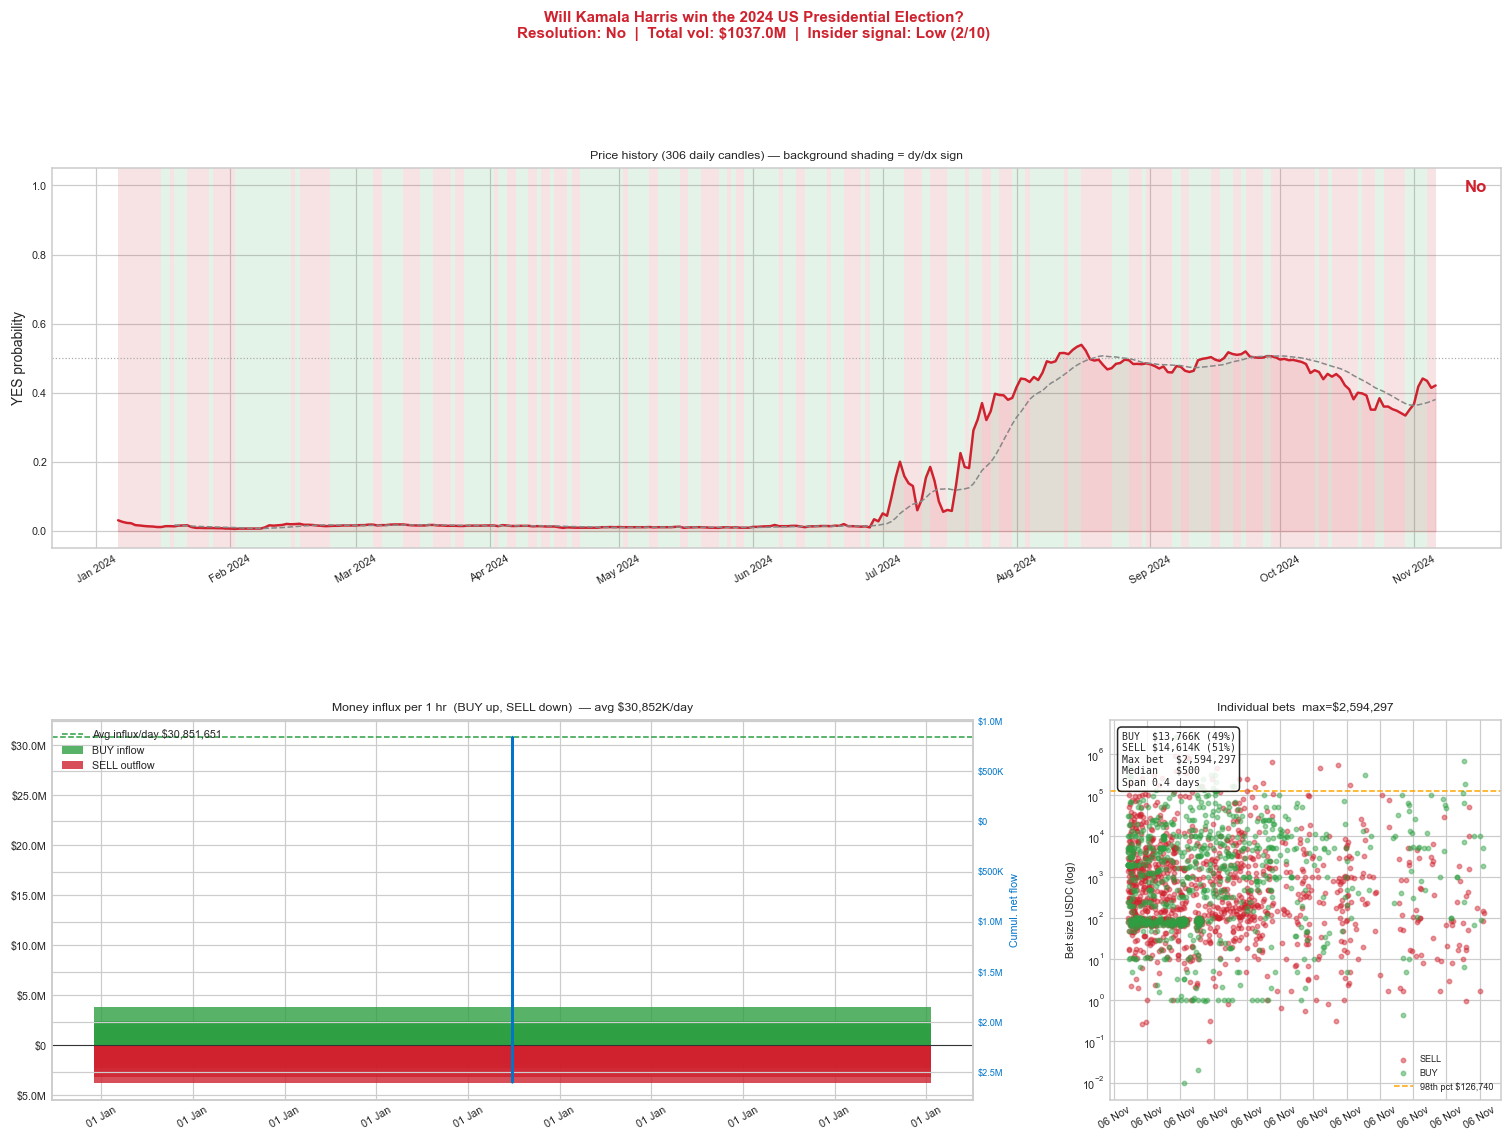

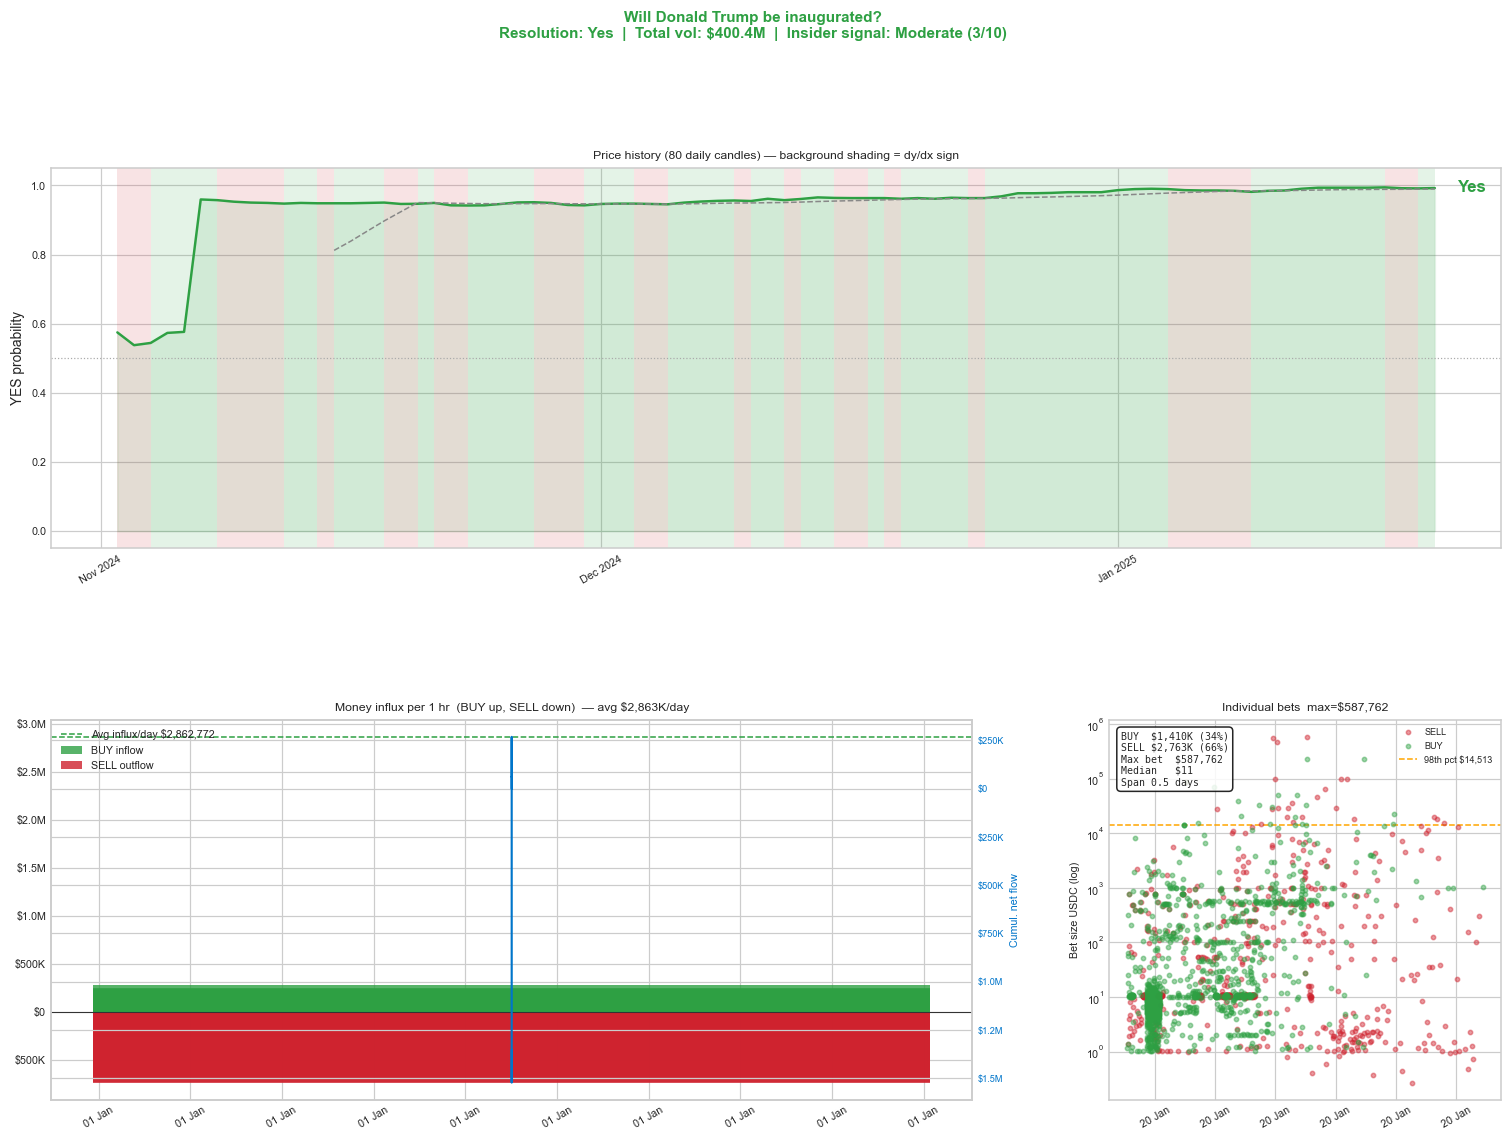

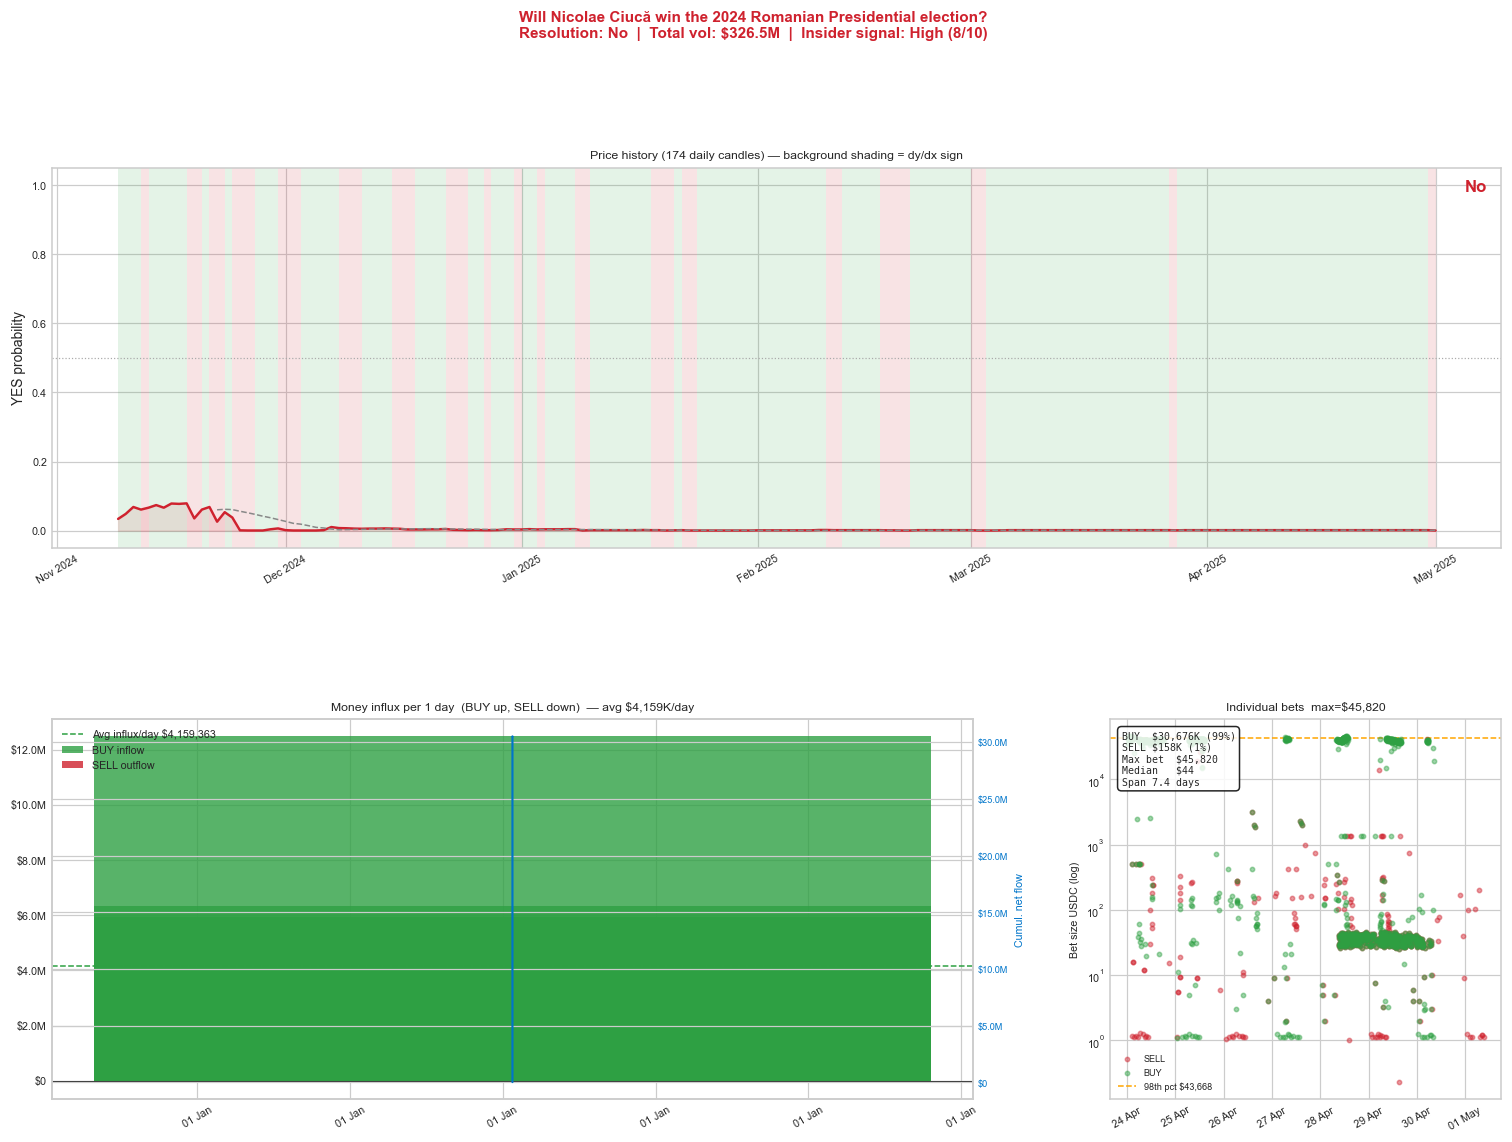

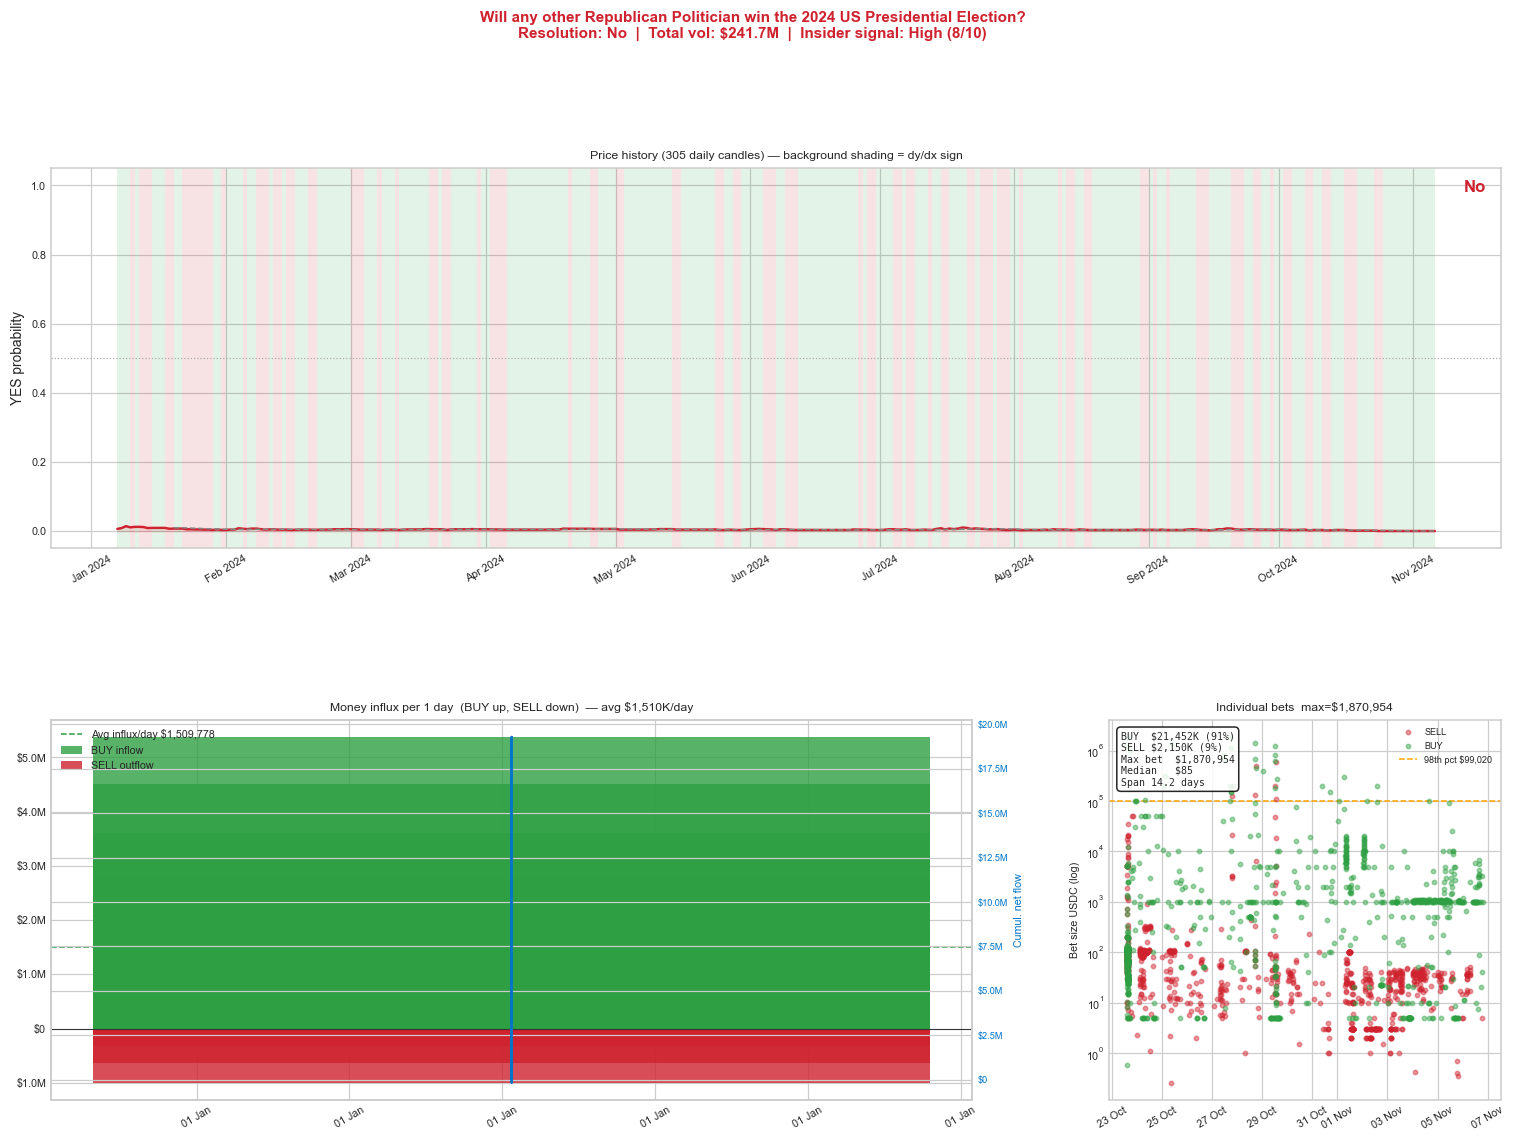

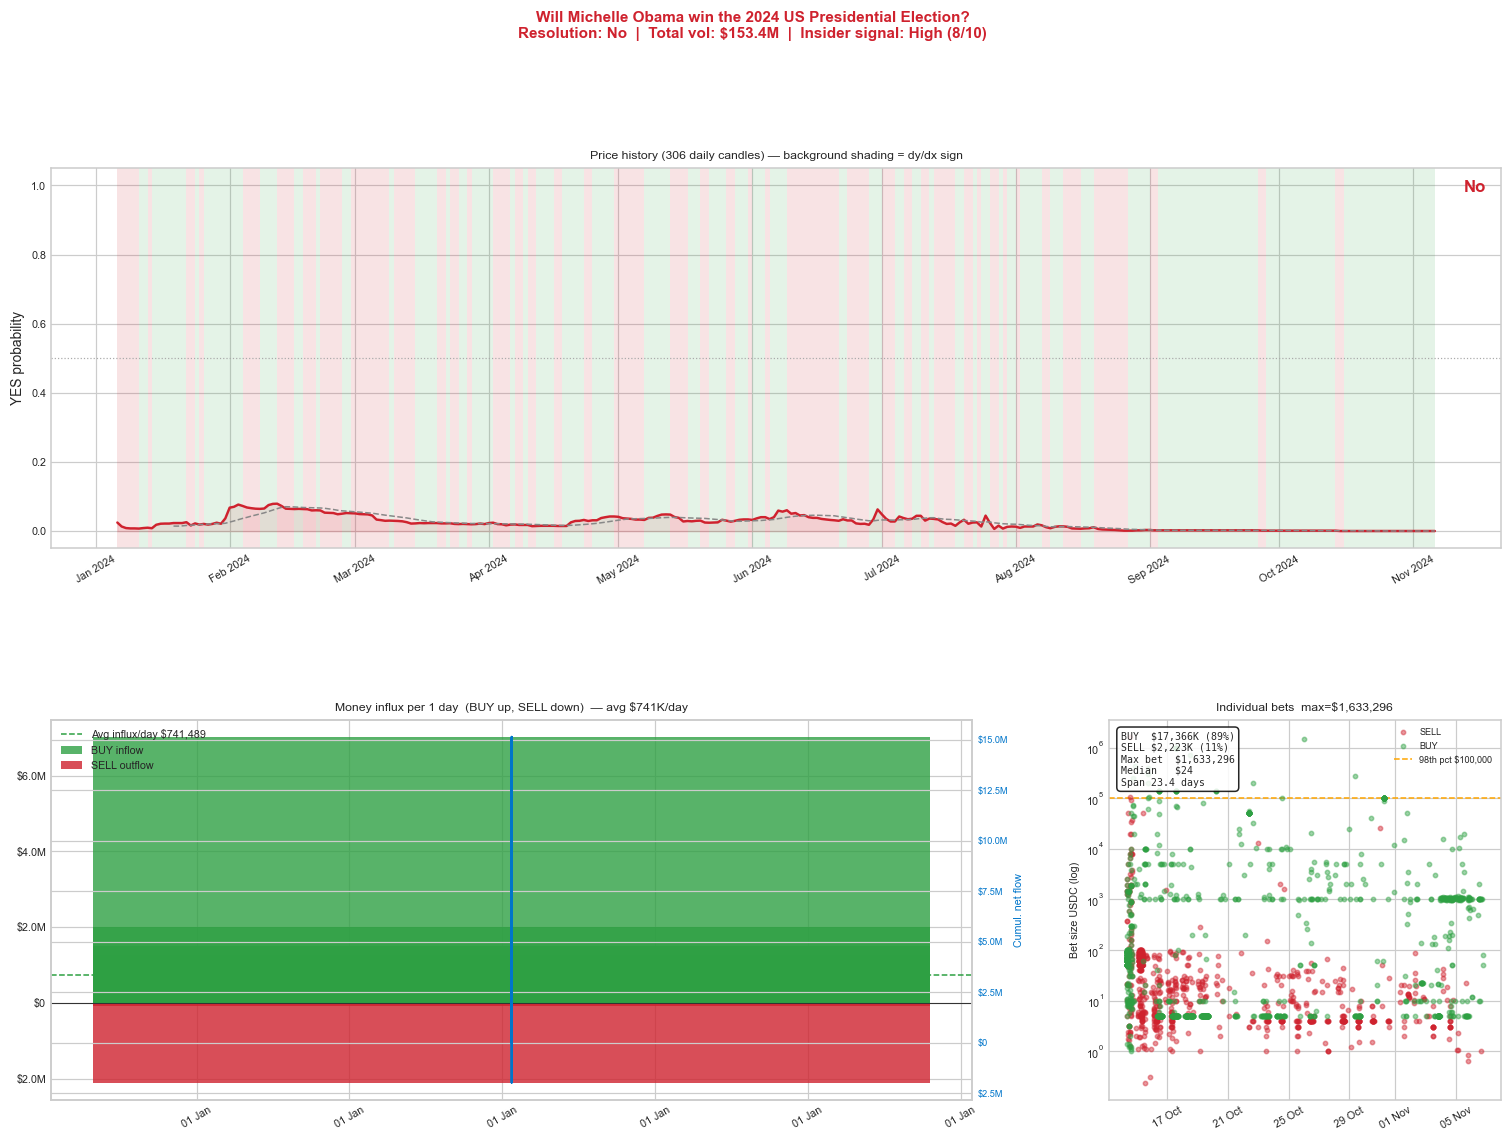

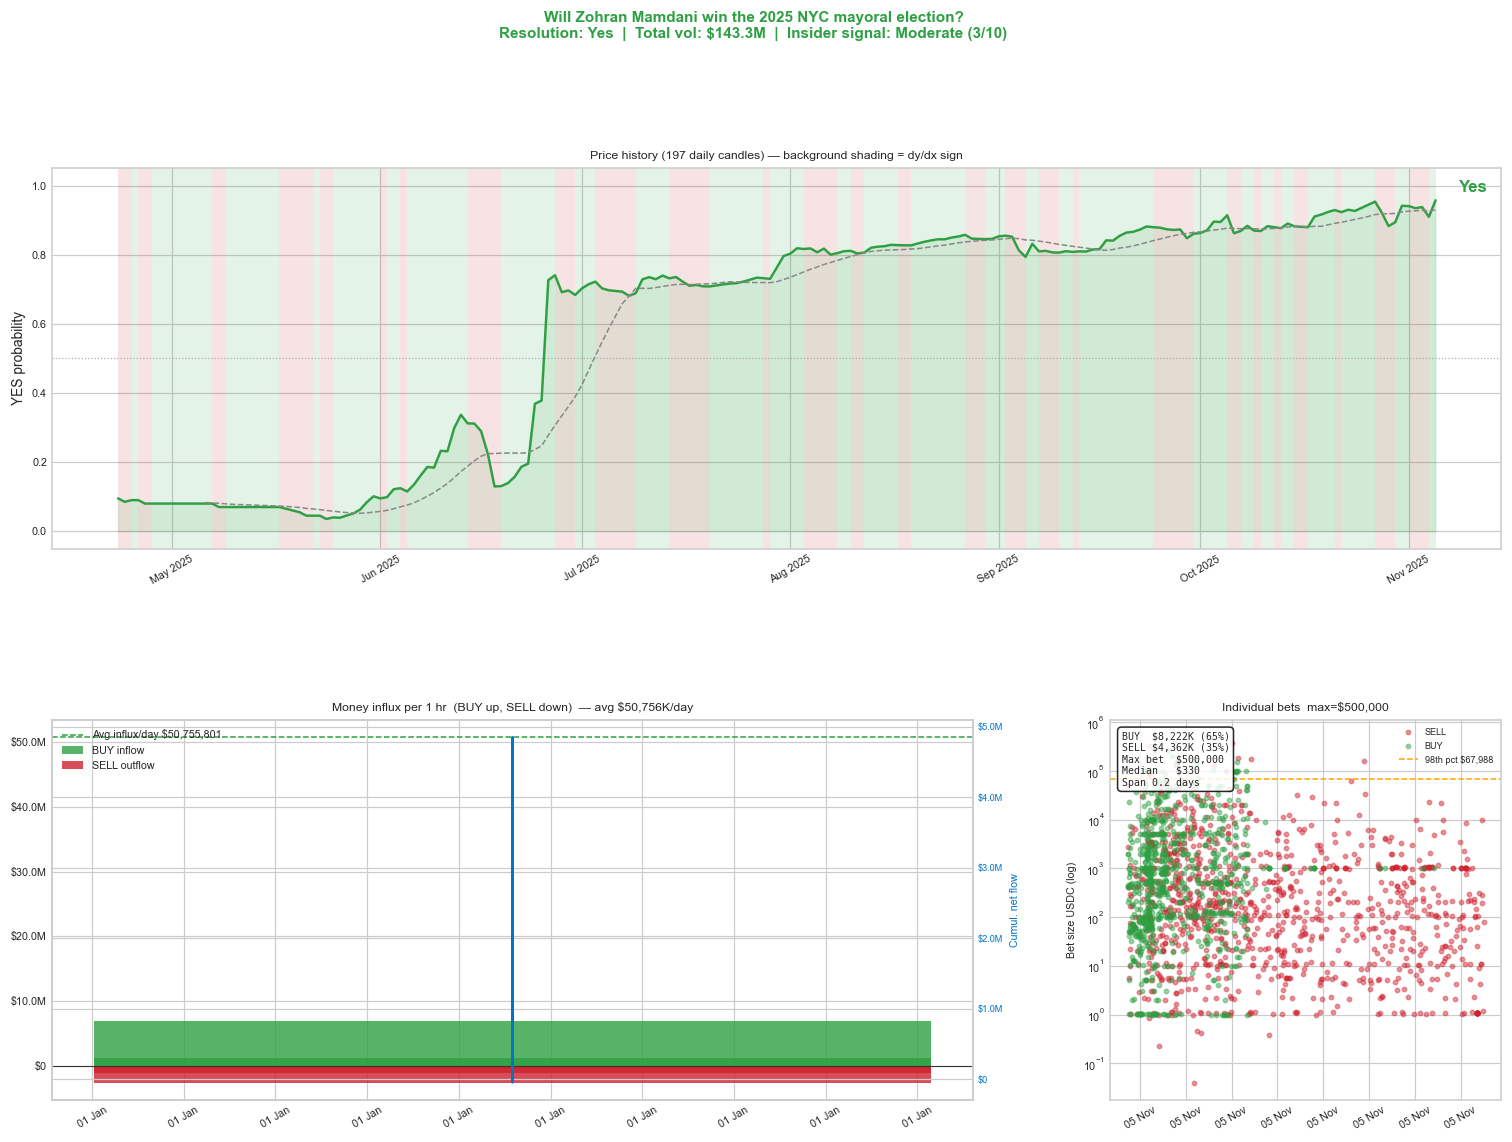

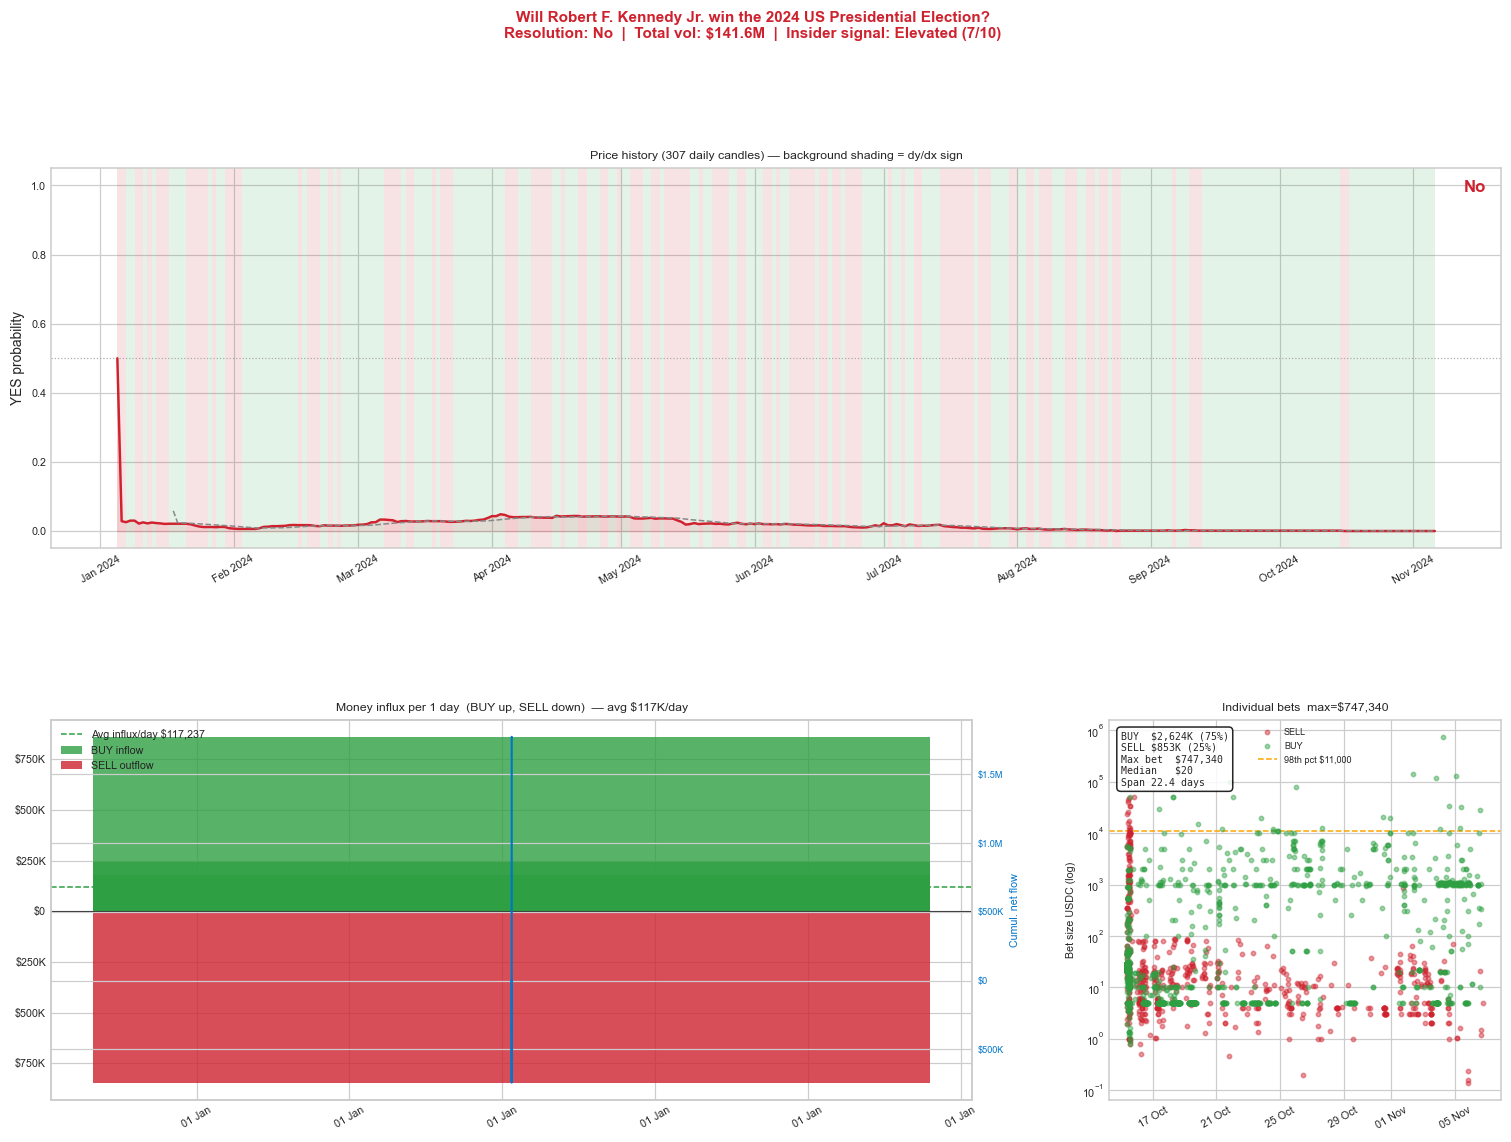

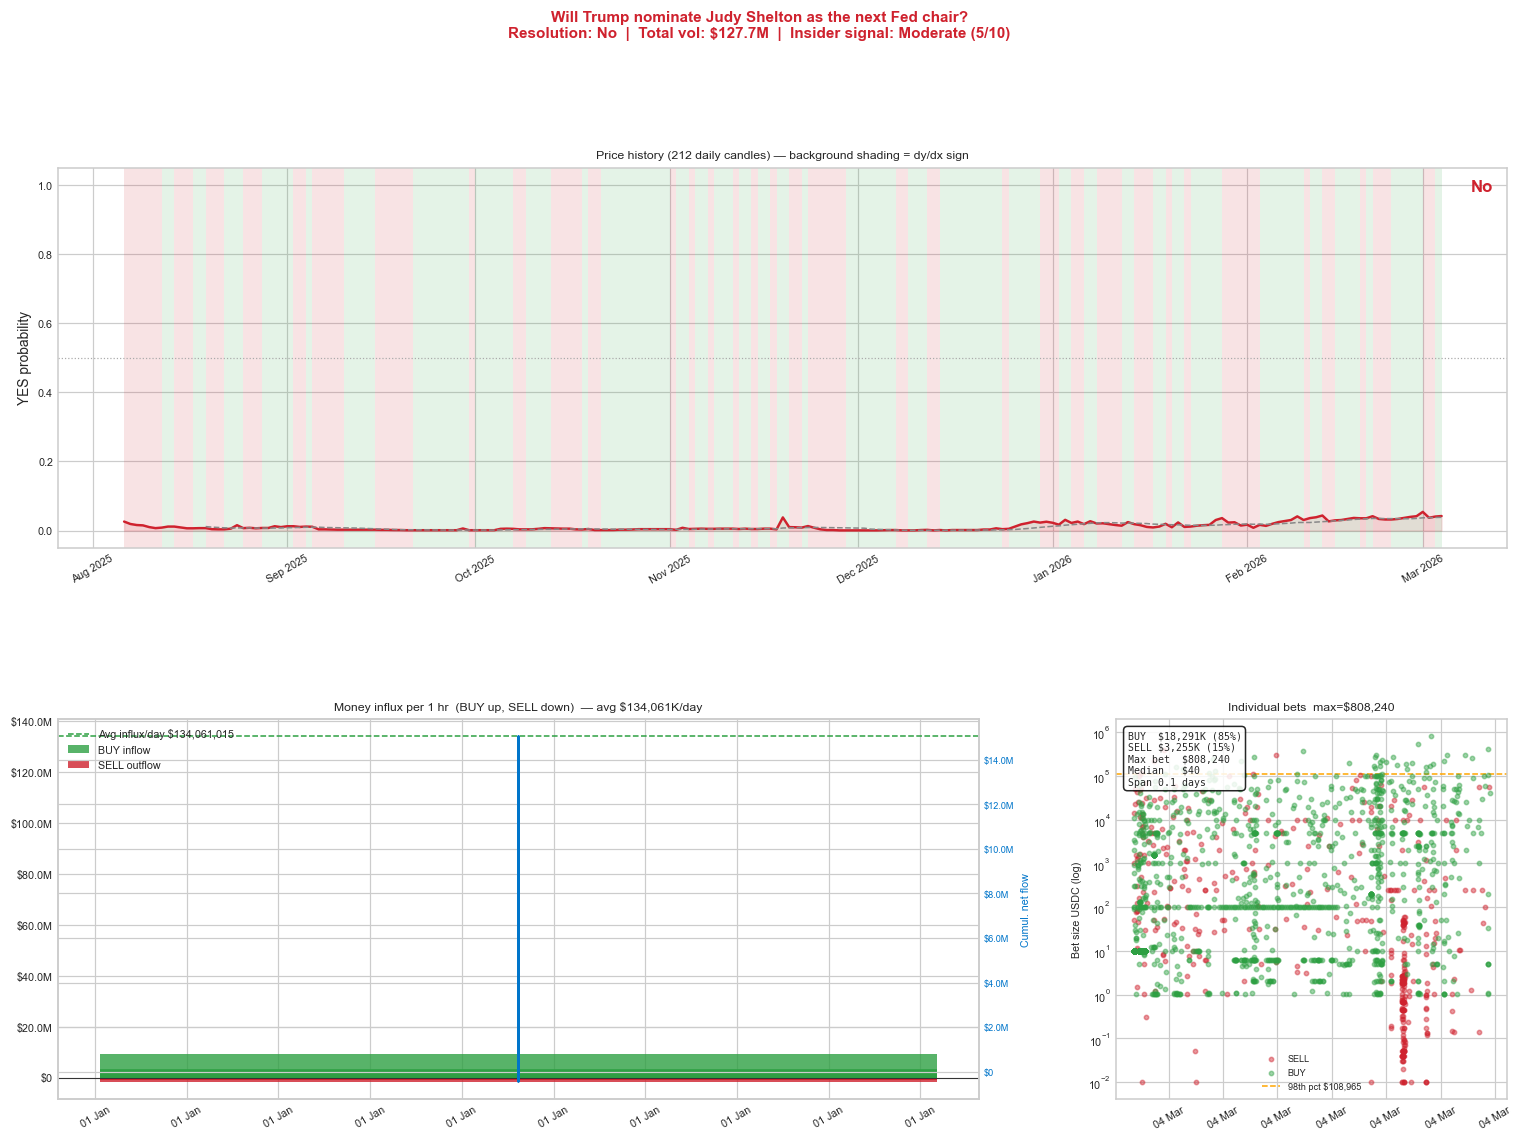

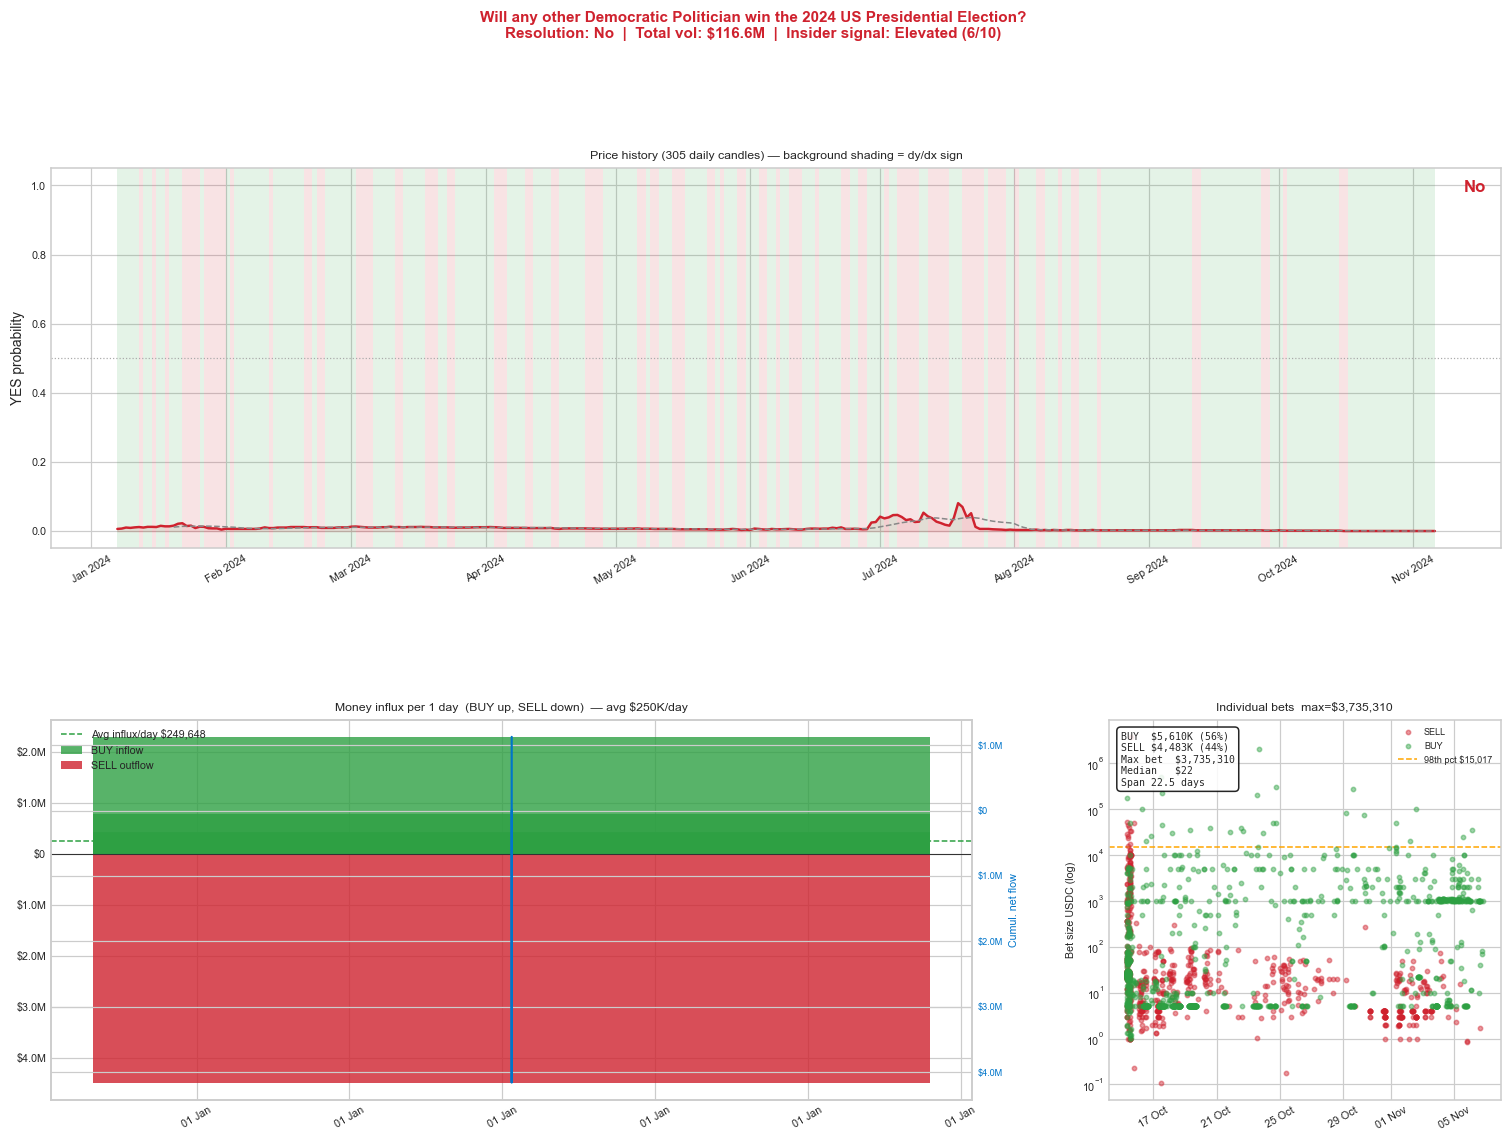

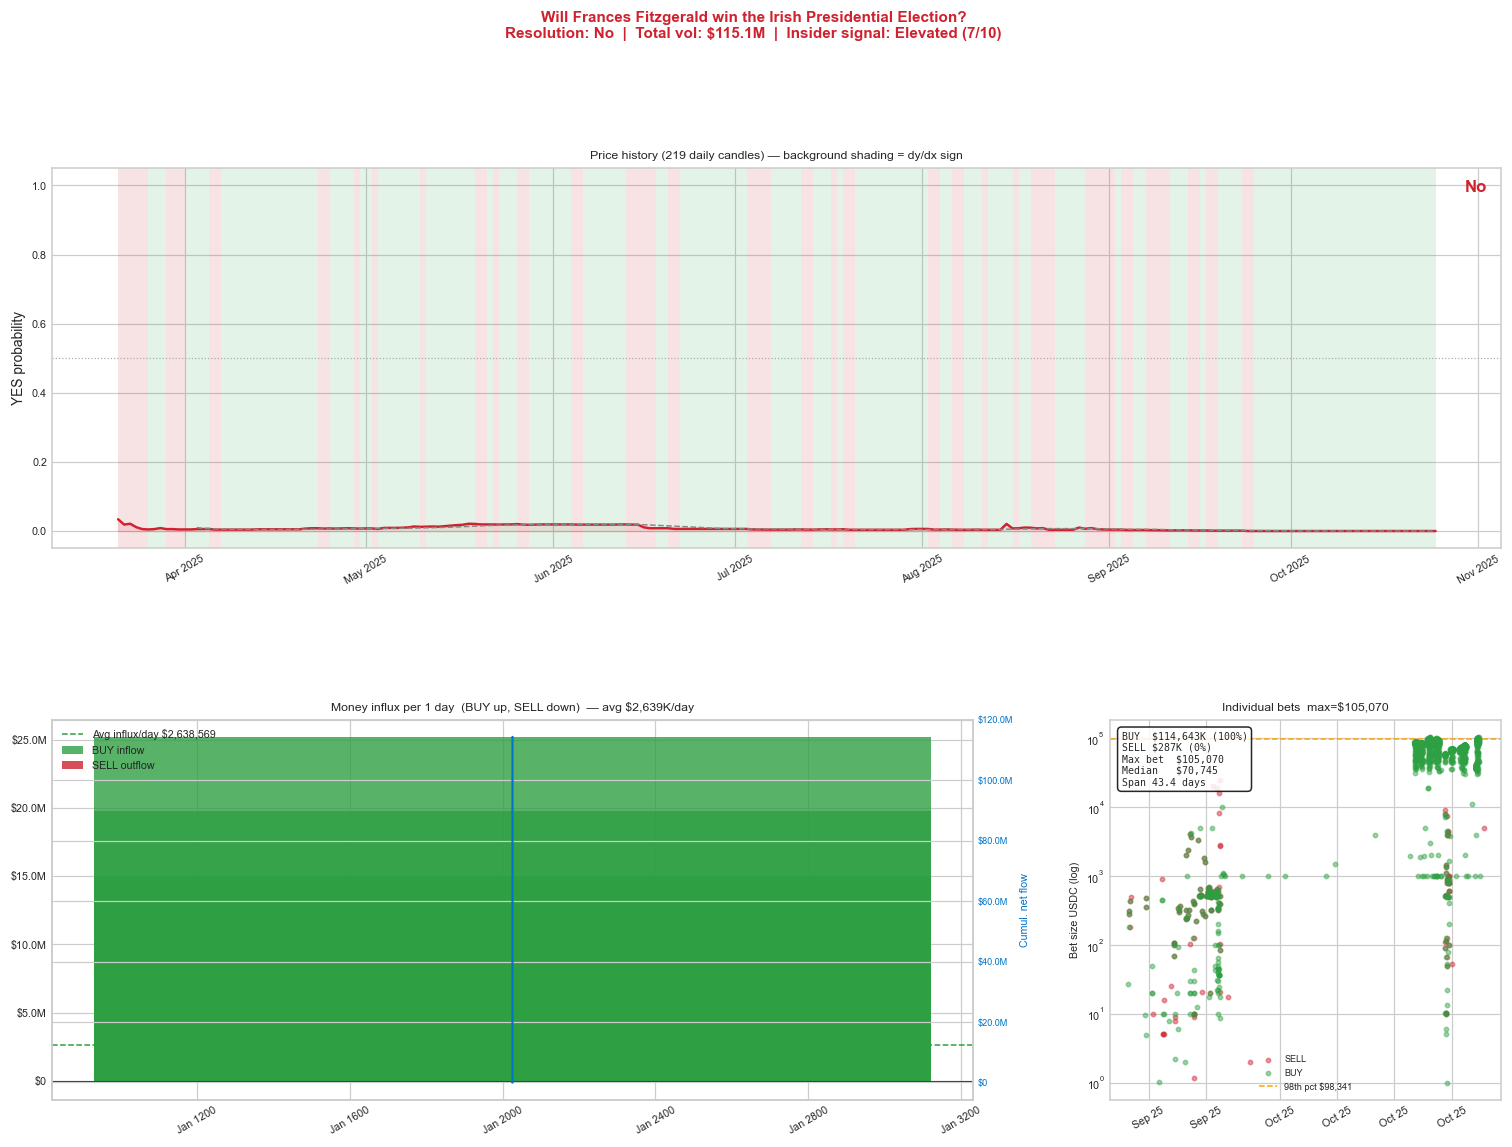

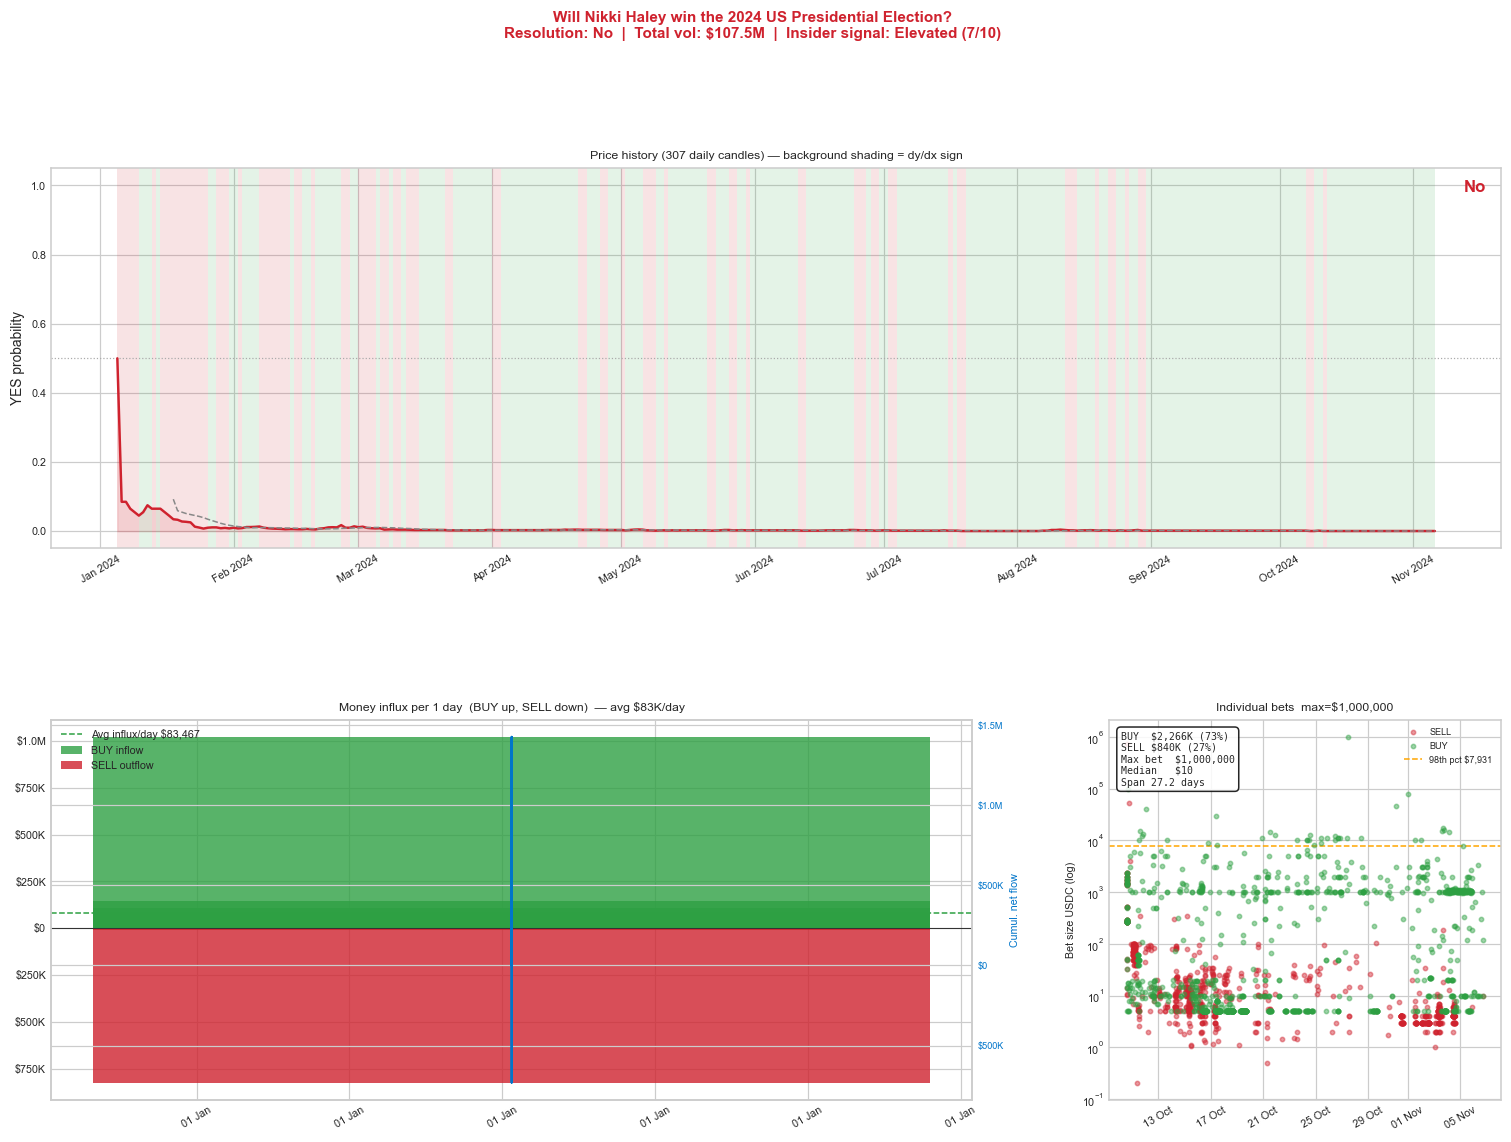

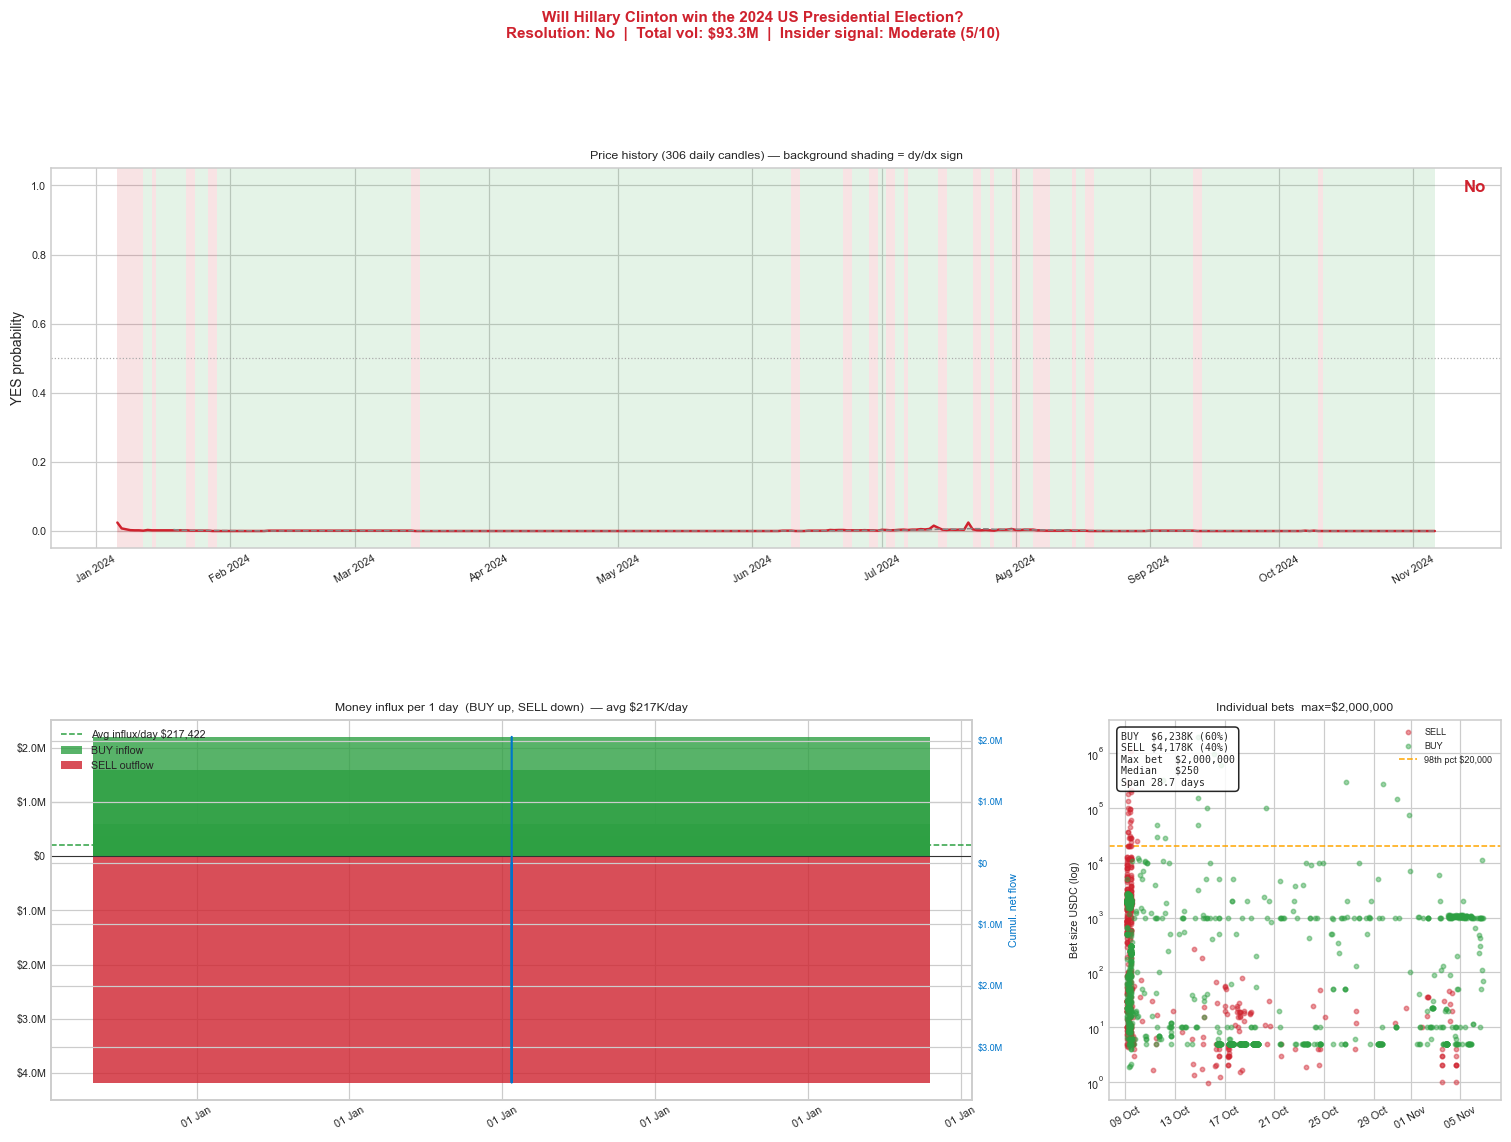

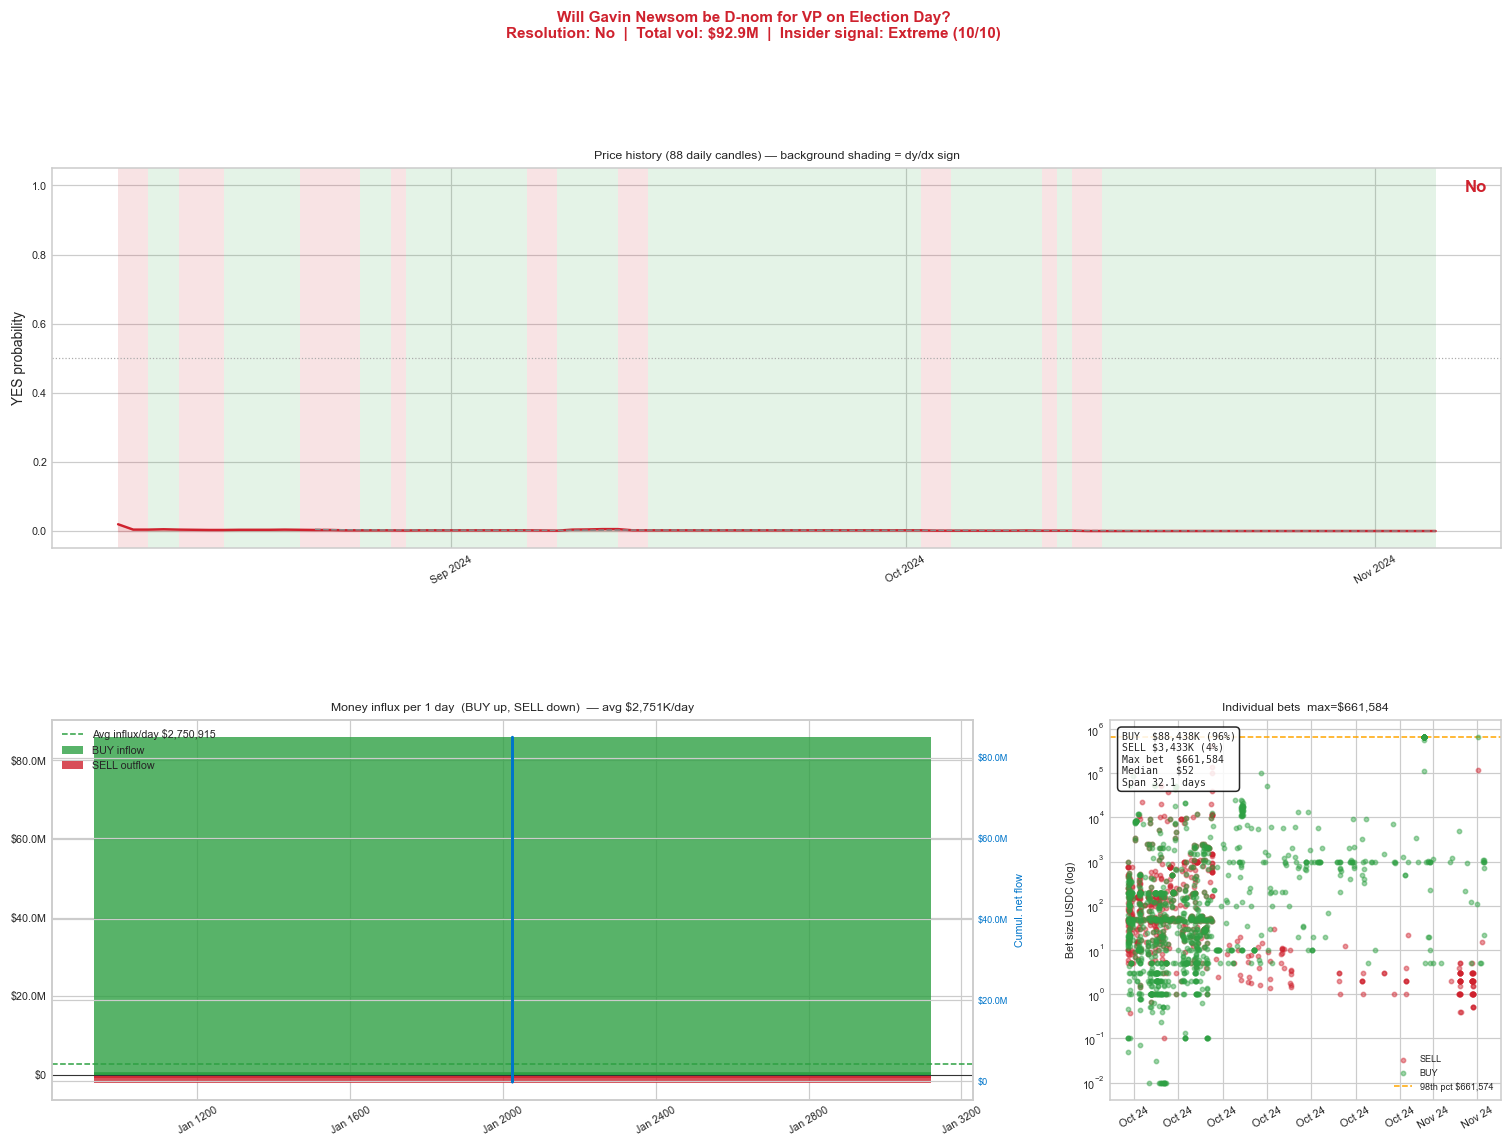

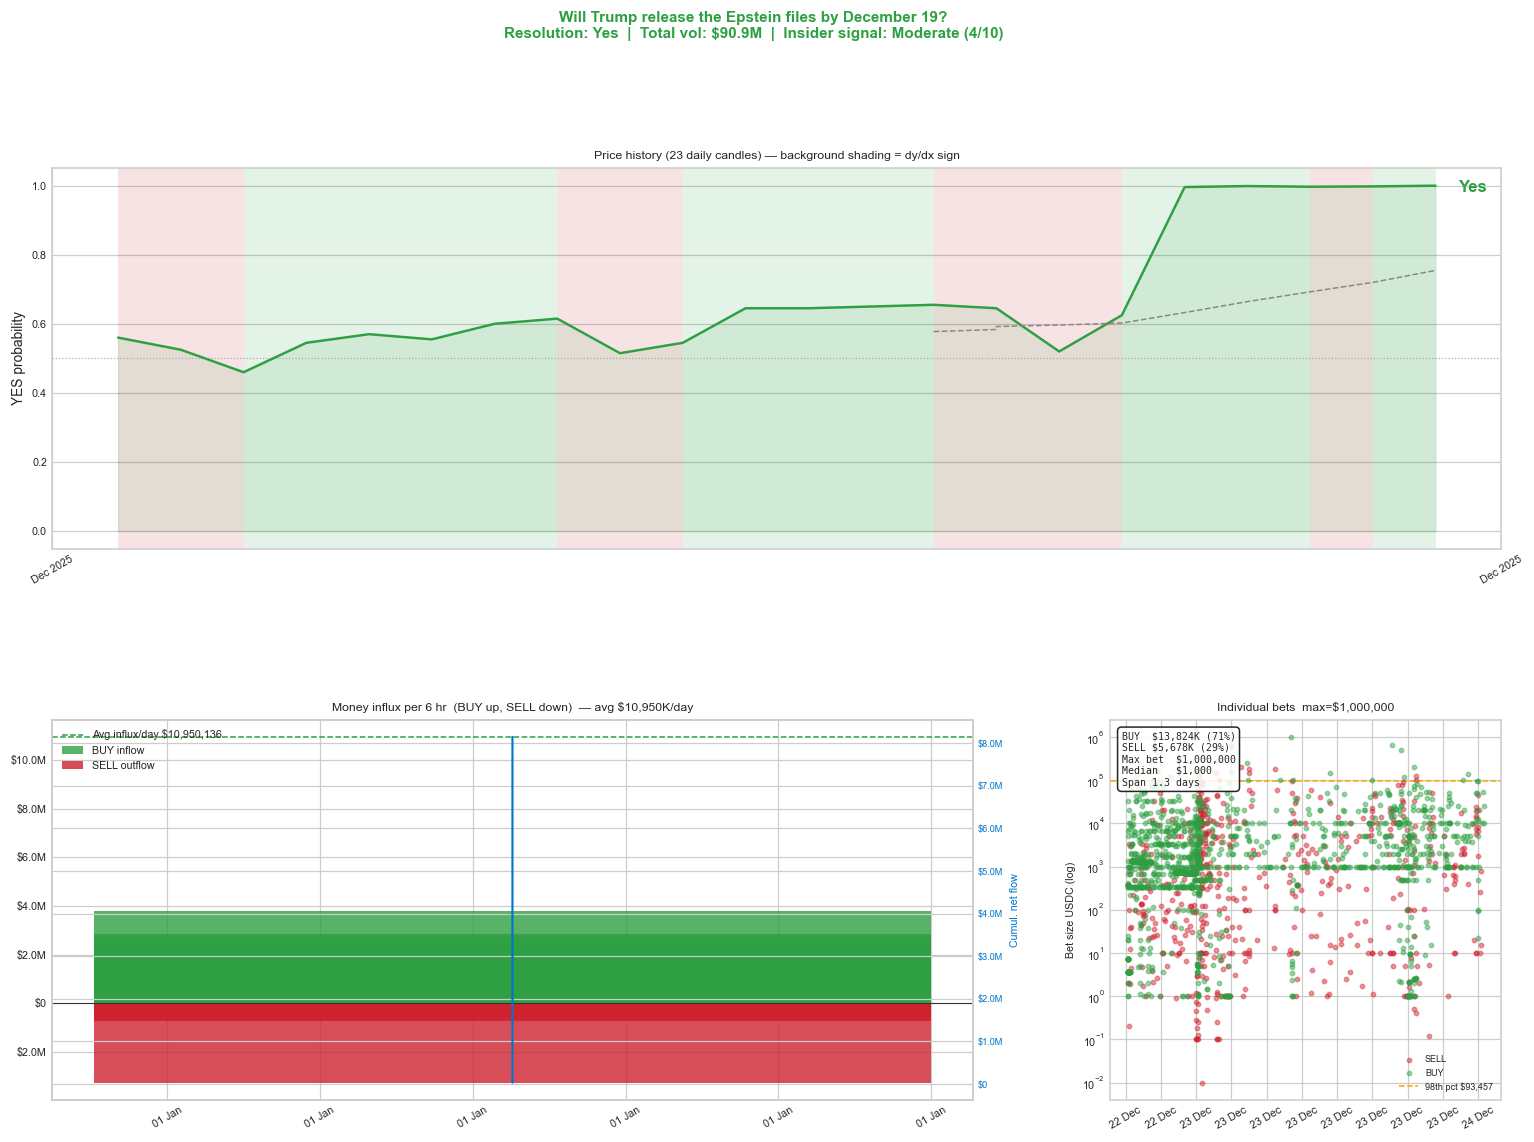

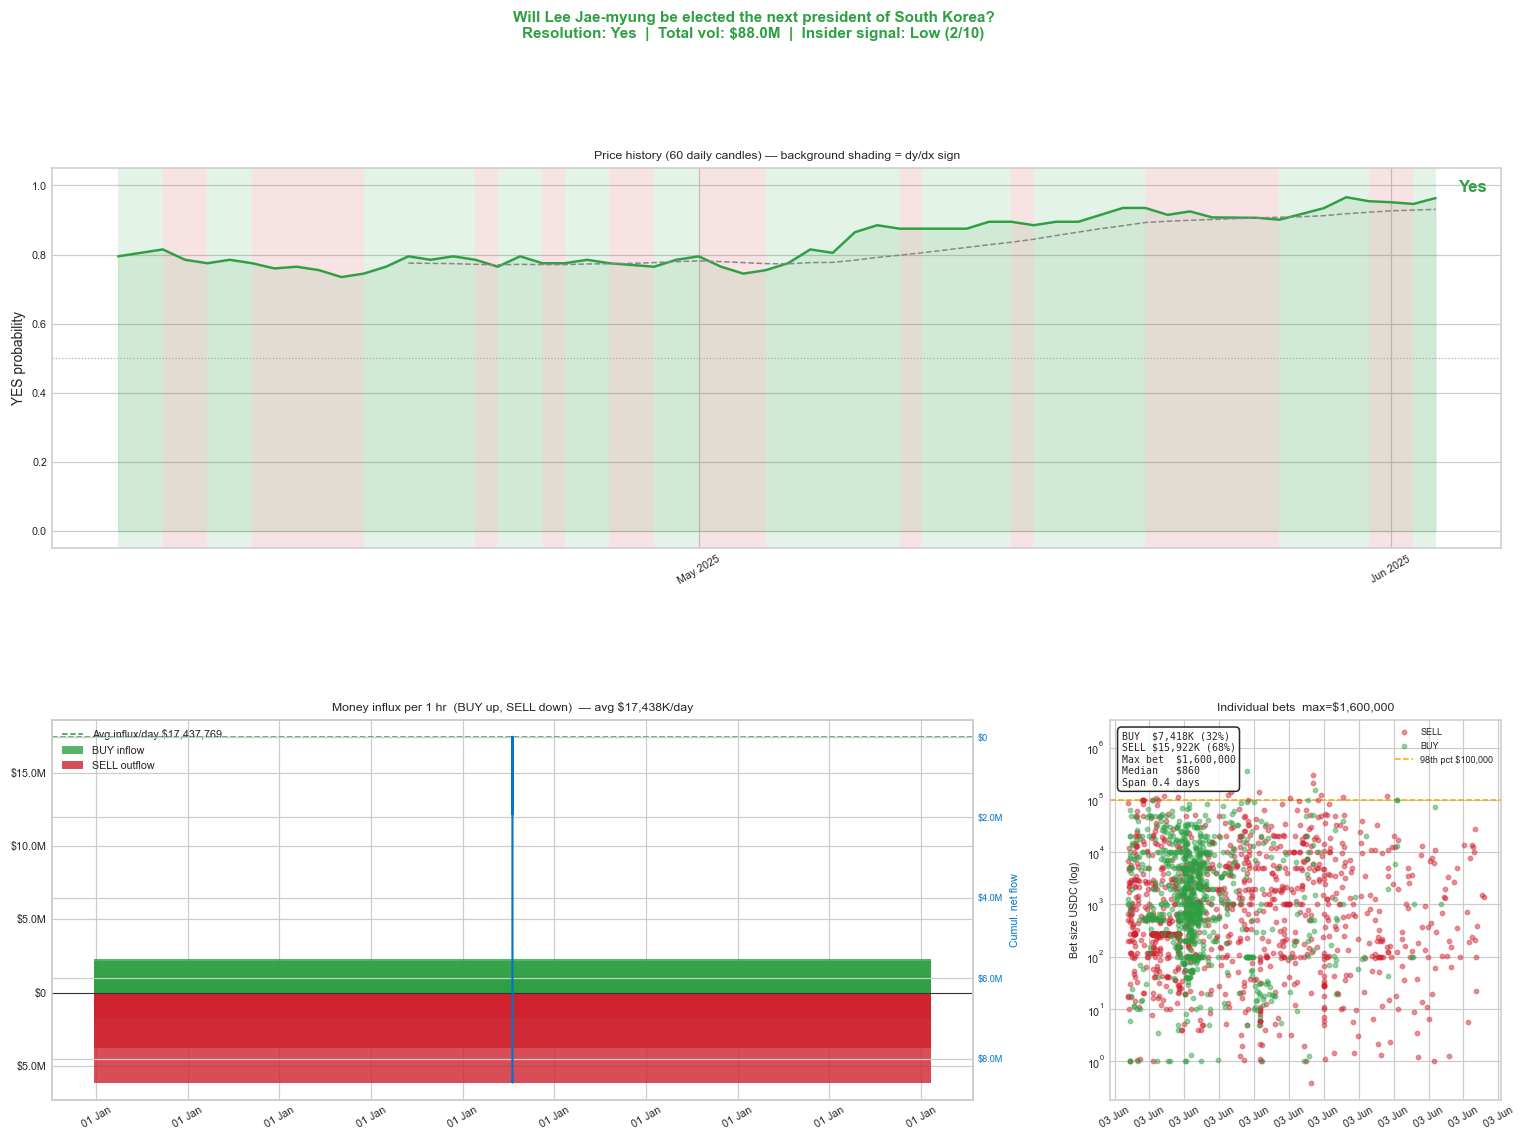

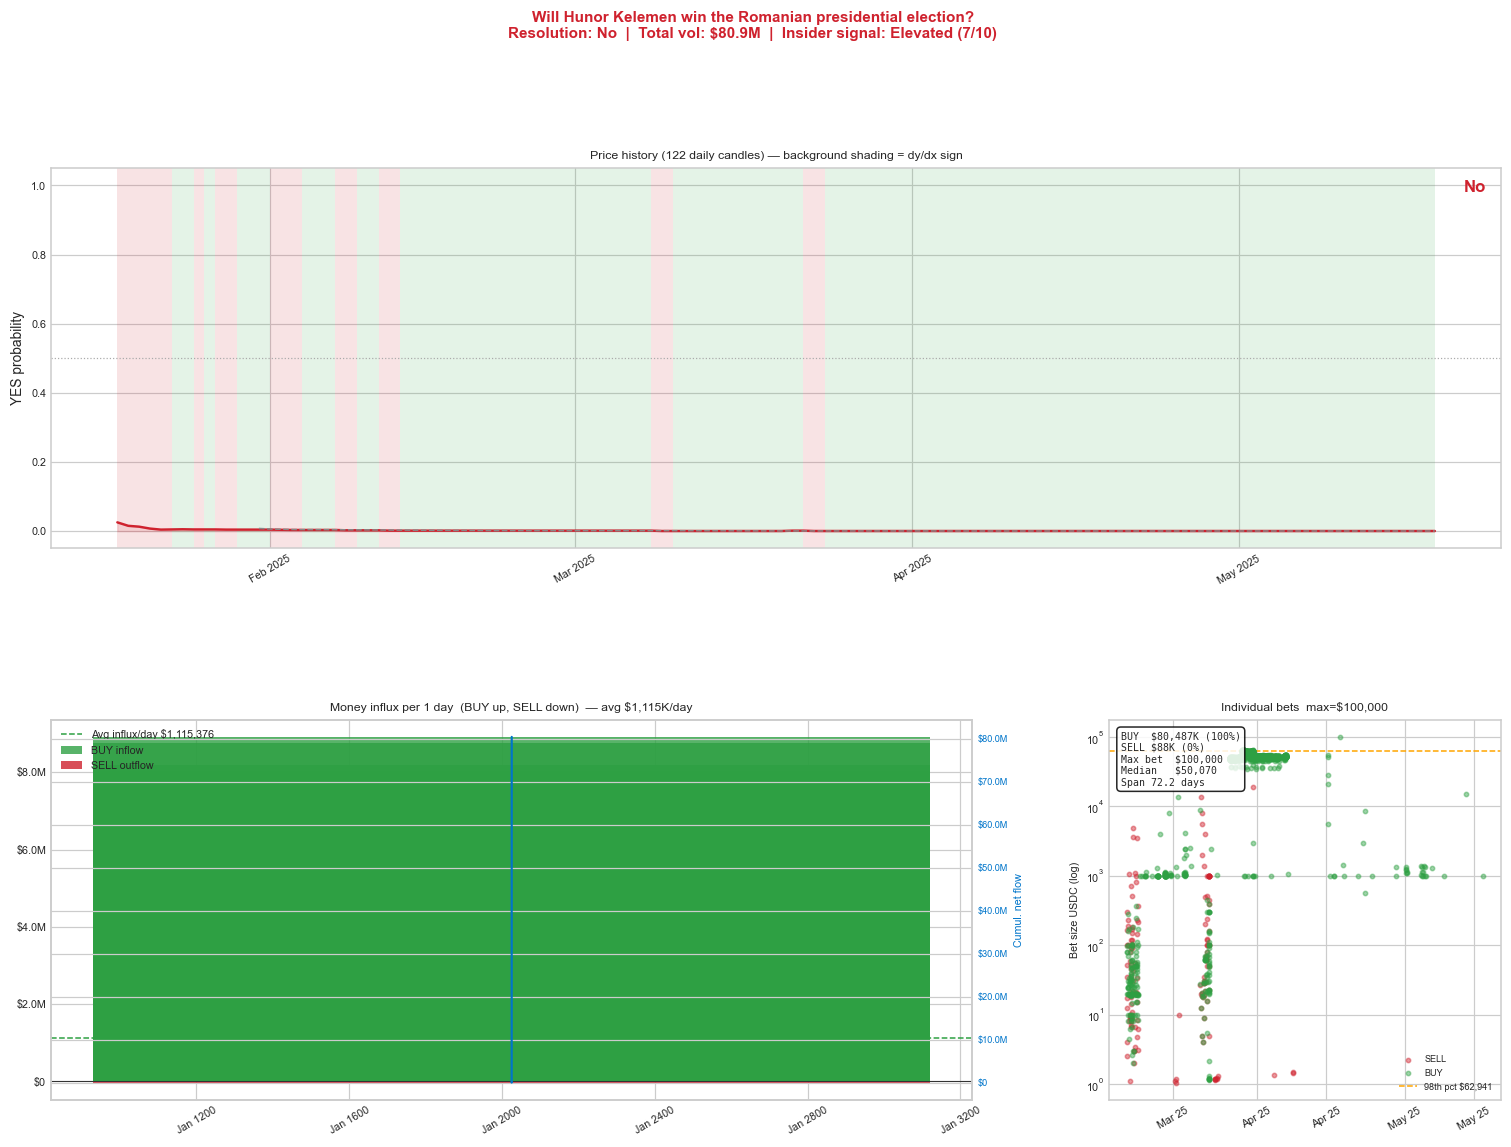

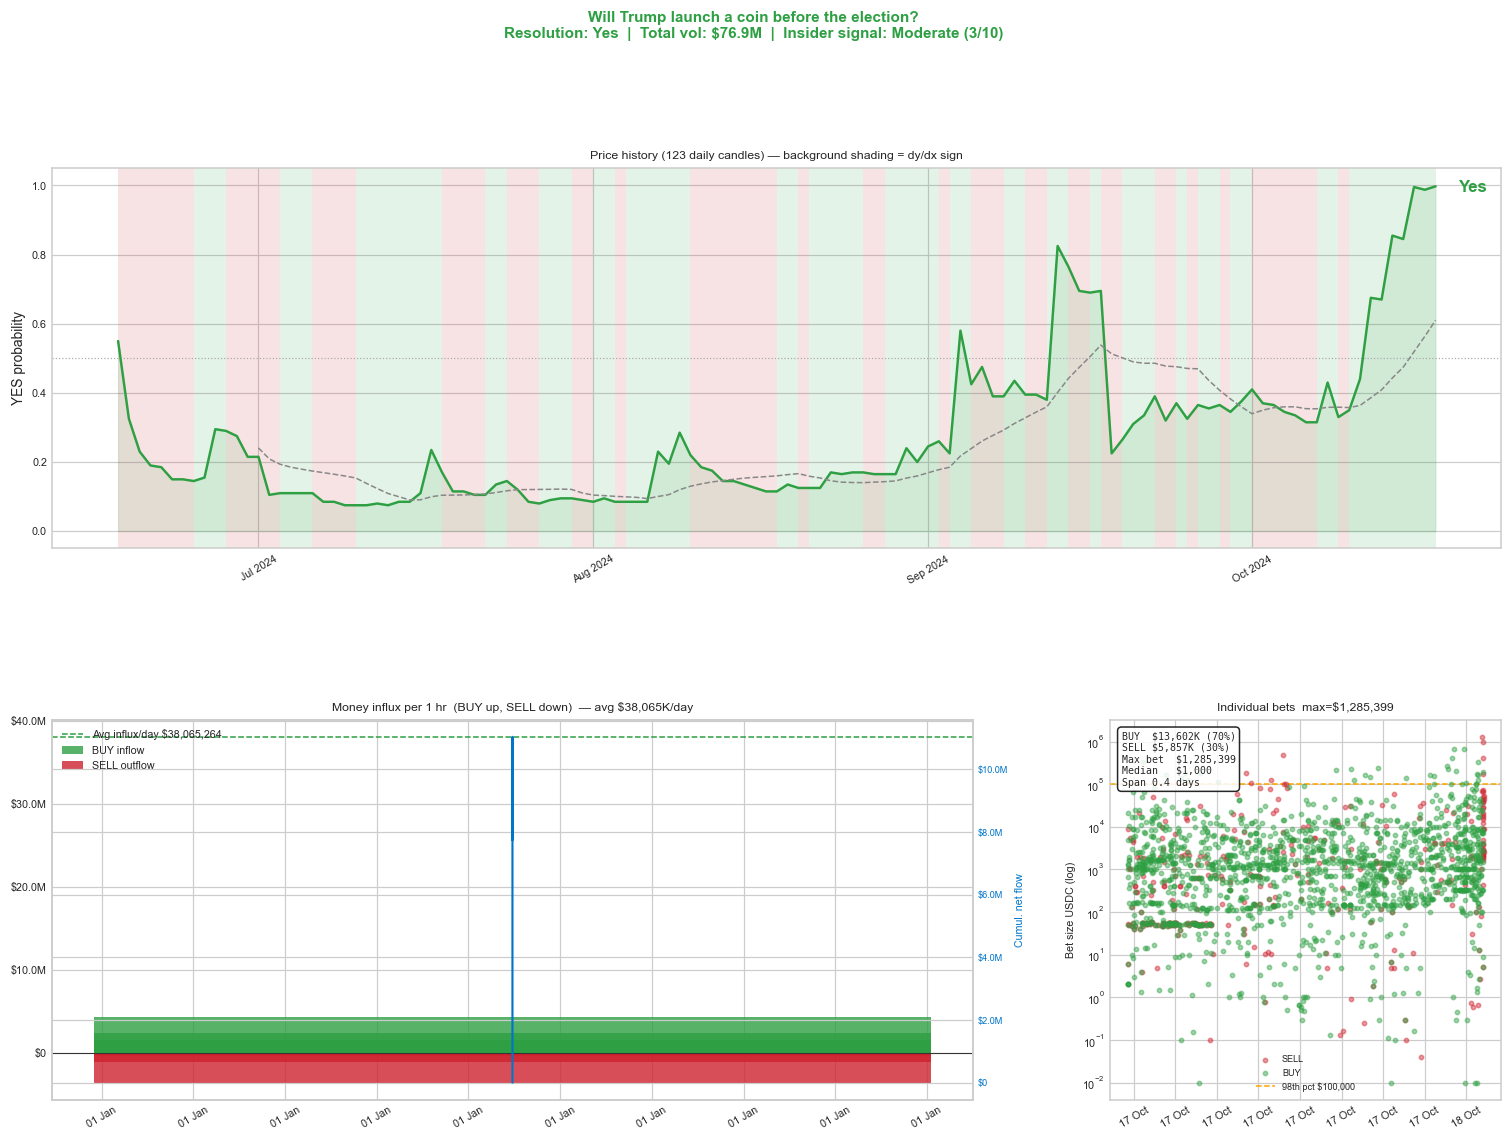

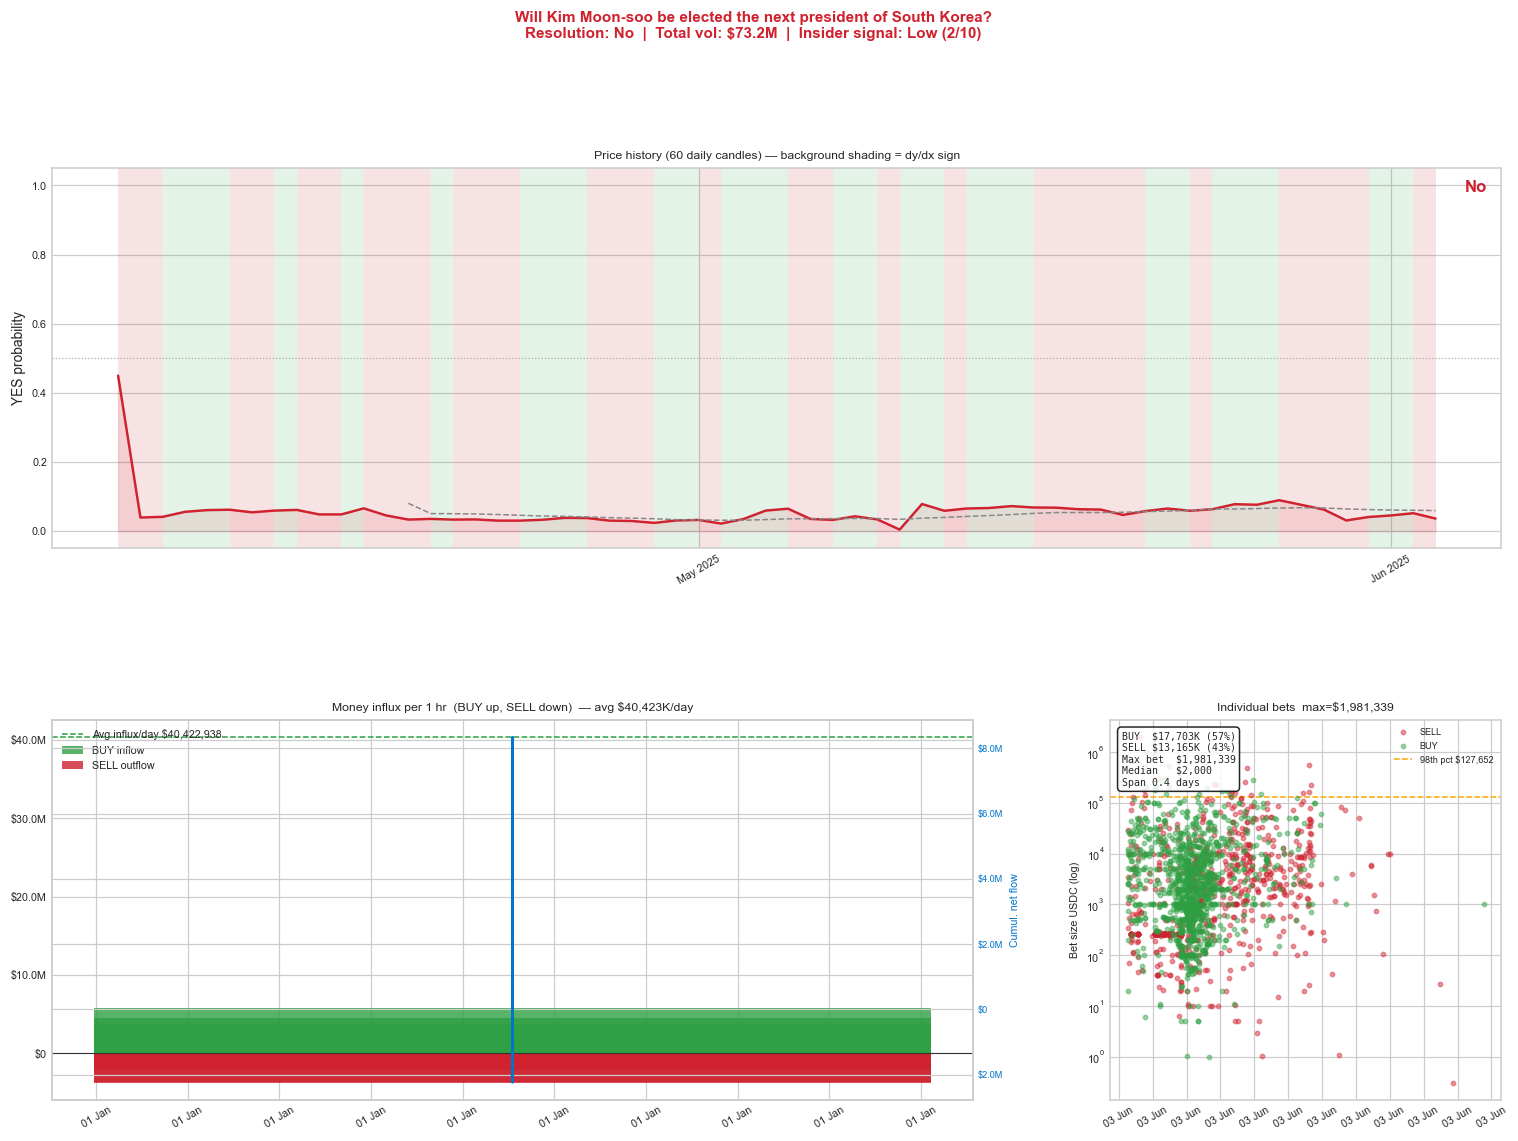

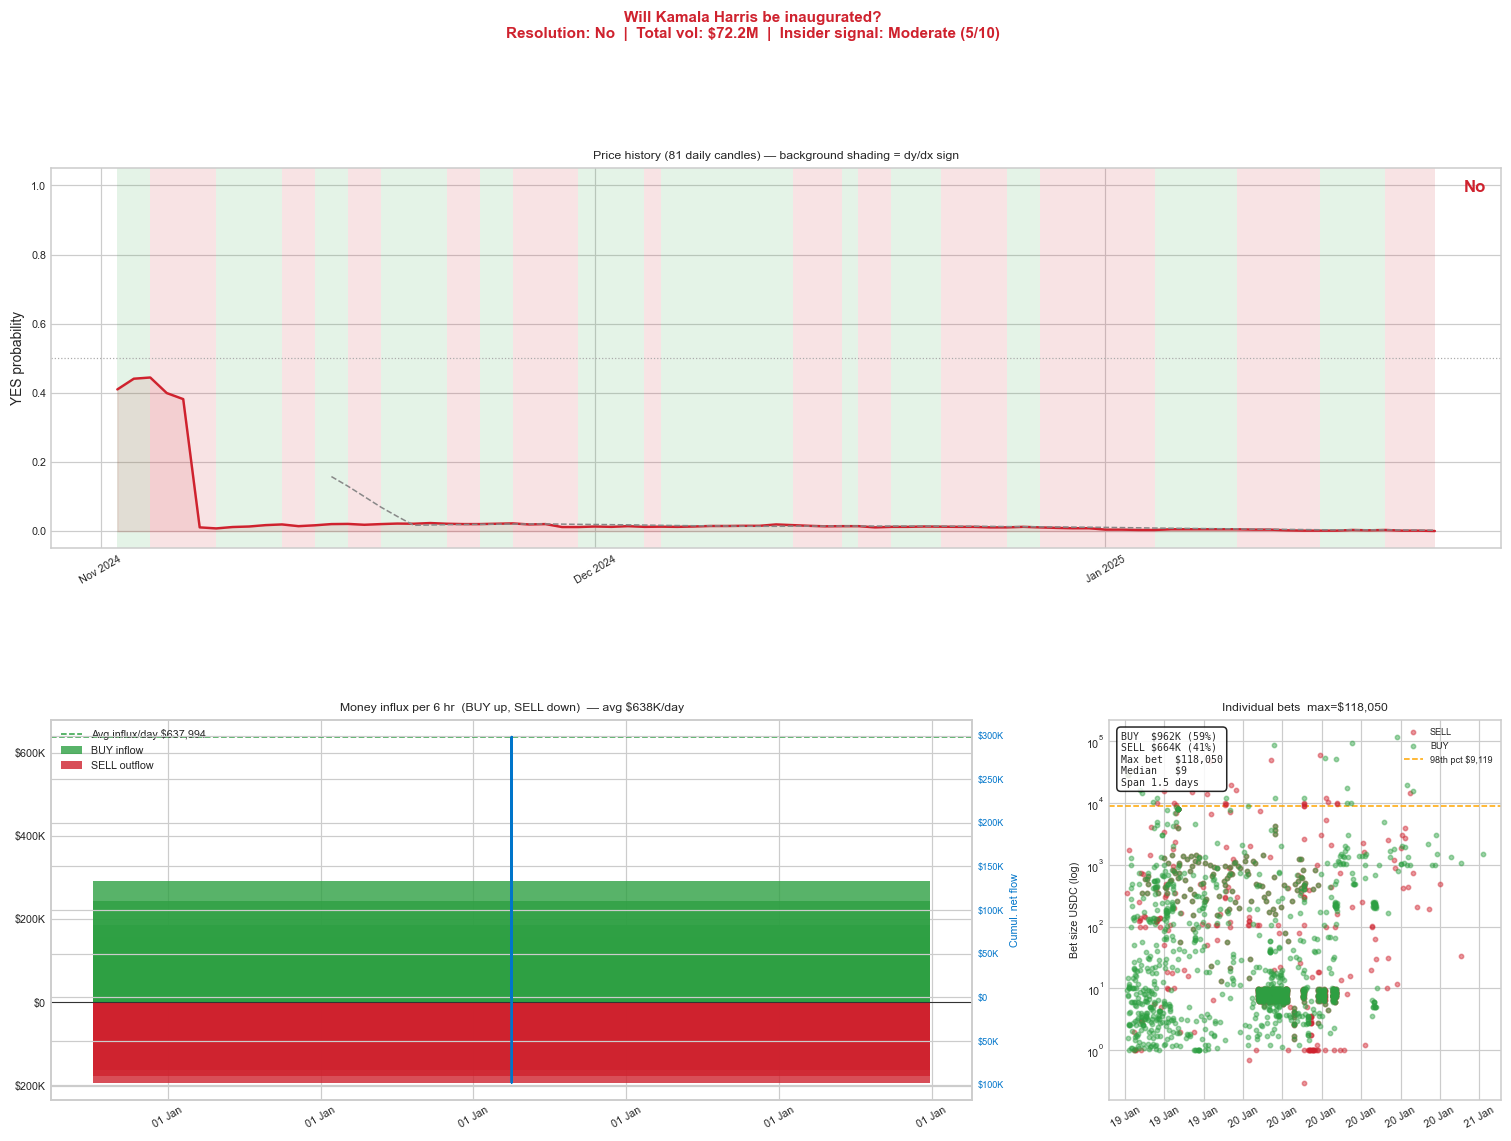


Analysed 20 markets


In [4]:
all_signals = []  # collect for ranking

for row in markets.sort('volume_usdc', descending=True).iter_rows(named=True):
    slug       = row['slug']
    question   = row['question']
    resolution = row['resolution']
    total_vol  = float(row['volume_usdc'] or 0)

    ph = load_ph(slug)
    tr = load_tr(slug)

    # --- Compute trade stats ---
    buy_vol = sell_vol = 0.0
    span_days = 0.0
    avg_influx_per_day = 0.0
    max_bet = median_bet = 0.0
    bucket_secs = 86400
    bucket_label = '1 day'

    has_trades = (tr is not None) and (len(tr) > 0)
    if has_trades:
        ts = tr['timestamp'].to_list()
        span_secs = max(ts) - min(ts)
        span_days = span_secs / 86400
        bucket_secs, bucket_label = bucket_size(span_secs)

        buys  = tr.filter(pl.col('side') == 'BUY')
        sells = tr.filter(pl.col('side') == 'SELL')
        buy_vol  = float(buys['size'].sum()  or 0)
        sell_vol = float(sells['size'].sum() or 0)

        all_sizes = tr['size'].drop_nulls().to_list()
        max_bet    = float(max(all_sizes)) if all_sizes else 0
        median_bet = float(np.median(all_sizes)) if all_sizes else 0

        avg_influx_per_day = buy_vol / max(span_days, 1/24)

        # Bucketed aggregation
        tr_b = tr.with_columns(
            ((pl.col('timestamp') // bucket_secs) * bucket_secs * 1_000_000)
            .cast(pl.Datetime('us')).alias('bucket')
        )
        grouped = (
            tr_b.group_by(['bucket', 'side'])
            .agg(pl.col('size').sum().alias('usdc'))
            .sort('bucket')
        )
        buy_bkts  = grouped.filter(pl.col('side') == 'BUY').sort('bucket')
        sell_bkts = grouped.filter(pl.col('side') == 'SELL').sort('bucket')

    score, label = insider_score(buy_vol, sell_vol, max_bet, median_bet, span_days)
    all_signals.append({
        'slug': slug, 'question': question[:65], 'resolution': resolution,
        'score': score, 'signal': label,
        'buy_vol': buy_vol, 'sell_vol': sell_vol,
        'buy_pct': 100 * buy_vol / (buy_vol + sell_vol) if (buy_vol + sell_vol) > 0 else 0,
        'max_bet': max_bet, 'avg_influx_per_day': avg_influx_per_day,
        'span_days': span_days,
    })

    # ── Build figure ─────────────────────────────────────────────────────
    is_yes = (resolution == 'Yes')
    c_res  = '#2ea043' if is_yes else '#cf222e'

    fig = plt.figure(figsize=(17, 11))
    fig.suptitle(
        f'{question}\n'
        f'Resolution: {resolution}  |  Total vol: ${total_vol/1e6:.1f}M  |  '
        f'Insider signal: {label} ({score}/10)',
        fontsize=10, fontweight='bold', color=c_res, y=1.01
    )
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    # ── Panel 1: full price timeline ──────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :])
    if len(ph) > 0:
        dates  = ph['date'].to_list()
        prices = np.array(ph['price'].to_list(), dtype=float)
        dydx   = np.gradient(prices)

        # Shade dy/dx background
        for i in range(len(dates) - 1):
            col = '#2ea04320' if dydx[i] >= 0 else '#cf222e20'
            ax1.axvspan(dates[i], dates[i+1], color=col, linewidth=0)

        ax1.plot(dates, prices, color=c_res, linewidth=1.6, zorder=3)
        ax1.fill_between(dates, prices, alpha=0.10, color=c_res, zorder=2)

        # 14-day rolling mean
        if len(prices) >= 14:
            rolling = np.convolve(prices, np.ones(14)/14, mode='valid')
            ax1.plot(dates[13:], rolling, color='#888', linewidth=1.0,
                     linestyle='--', label='14d avg', zorder=4)

        ax1.axhline(0.5, color='#aaa', linestyle=':', linewidth=0.8)
        ax1.set_ylim(-0.05, 1.05)
        ax1.set_ylabel('YES probability')
        ax1.set_title(f'Price history ({len(ph)} daily candles) — background shading = dy/dx sign',
                      fontsize=8)
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30)
        ax1.text(0.99, 0.97, resolution, transform=ax1.transAxes,
                 ha='right', va='top', fontsize=11, fontweight='bold', color=c_res)
    else:
        ax1.text(0.5, 0.5, 'No price data', ha='center', va='center', transform=ax1.transAxes)

    # ── Panel 2: money influx per bucket ────────────────────────────────
    ax2 = fig.add_subplot(gs[1, :2])
    if has_trades:
        b_dates = buy_bkts['bucket'].to_list()
        b_usdc  = buy_bkts['usdc'].to_list()
        s_dates = sell_bkts['bucket'].to_list()
        s_usdc  = sell_bkts['usdc'].to_list()

        ax2.bar(b_dates, b_usdc,  width=0.8*bucket_secs*1e6/86400,
                color=C_BUY,  alpha=0.8, label='BUY inflow')
        ax2.bar(s_dates, [-v for v in s_usdc], width=0.8*bucket_secs*1e6/86400,
                color=C_SELL, alpha=0.8, label='SELL outflow')
        ax2.axhline(0, color='#333', linewidth=0.7)
        ax2.axhline( avg_influx_per_day, color=C_BUY, linewidth=1.0,
                    linestyle='--', label=f'Avg influx/day ${avg_influx_per_day:,.0f}')
        ax2.yaxis.set_major_formatter(fmt_usdc)
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b' if span_days < 30 else '%b %Y'))
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)
        ax2.set_title(f'Money influx per {bucket_label}  (BUY up, SELL down)  '
                      f'— avg ${avg_influx_per_day/1e3:,.0f}K/day', fontsize=8)
        ax2.legend(fontsize=7, loc='upper left')

        # Cumulative net flow on twin axis
        all_b = (tr.filter(pl.col('side') == 'BUY')
                 .with_columns(pl.col('size').alias('net'))
                 .select(['date','net']))
        all_s = (tr.filter(pl.col('side') == 'SELL')
                 .with_columns((-pl.col('size')).alias('net'))
                 .select(['date','net']))
        net_df = pl.concat([all_b, all_s]).sort('date')
        cum_net = np.cumsum(net_df['net'].to_list())
        ax2b = ax2.twinx()
        ax2b.plot(net_df['date'].to_list(), cum_net, color=C_NET,
                  linewidth=1.4, label='Cumul. net')
        ax2b.yaxis.set_major_formatter(fmt_usdc)
        ax2b.set_ylabel('Cumul. net flow', color=C_NET, fontsize=7)
        ax2b.tick_params(axis='y', colors=C_NET, labelsize=6)
    else:
        ax2.text(0.5, 0.5, 'No trade data', ha='center', va='center', transform=ax2.transAxes)

    # ── Panel 3: individual bet sizes ────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 2])
    if has_trades:
        for side, hex_col in [('SELL', C_SELL), ('BUY', C_BUY)]:
            sub = tr.filter(pl.col('side') == side)
            if not sub.is_empty():
                sizes_s = sub['size'].to_list()
                ax3.scatter(sub['date'].to_list(), sizes_s,
                            s=8, alpha=0.45, color=hex_col, label=side, zorder=3)

        all_s = tr['size'].drop_nulls().to_list()
        if all_s:
            thresh = np.percentile(all_s, 98)
            ax3.axhline(thresh, color='orange', linewidth=1.0, linestyle='--',
                        label=f'98th pct ${thresh:,.0f}')
            ax3.set_yscale('log')

        ax3.xaxis.set_major_formatter(mdates.DateFormatter('%d %b' if span_days < 30 else '%b %y'))
        plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30)
        ax3.set_ylabel('Bet size USDC (log)', fontsize=7)
        ax3.set_title(f'Individual bets  max=${max_bet:,.0f}', fontsize=8)
        ax3.legend(fontsize=6)

        # Stats box
        total = buy_vol + sell_vol
        buy_pct = 100 * buy_vol / total if total > 0 else 0
        stats_txt = (
            f'BUY  ${buy_vol/1e3:,.0f}K ({buy_pct:.0f}%)\n'
            f'SELL ${sell_vol/1e3:,.0f}K ({100-buy_pct:.0f}%)\n'
            f'Max bet  ${max_bet:,.0f}\n'
            f'Median   ${median_bet:,.0f}\n'
            f'Span {span_days:.1f} days'
        )
        ax3.text(0.03, 0.97, stats_txt, transform=ax3.transAxes, fontsize=6.5,
                 va='top', ha='left', fontfamily='monospace',
                 bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))
    else:
        ax3.text(0.5, 0.5, 'No trade data', ha='center', va='center', transform=ax3.transAxes)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

print(f'\nAnalysed {len(all_signals)} markets')

## Insider signal ranking
Markets ranked by signal score. Score factors: **BUY dominance** (0-4), **whale concentration** (0-3), **accumulation span** (0-3).

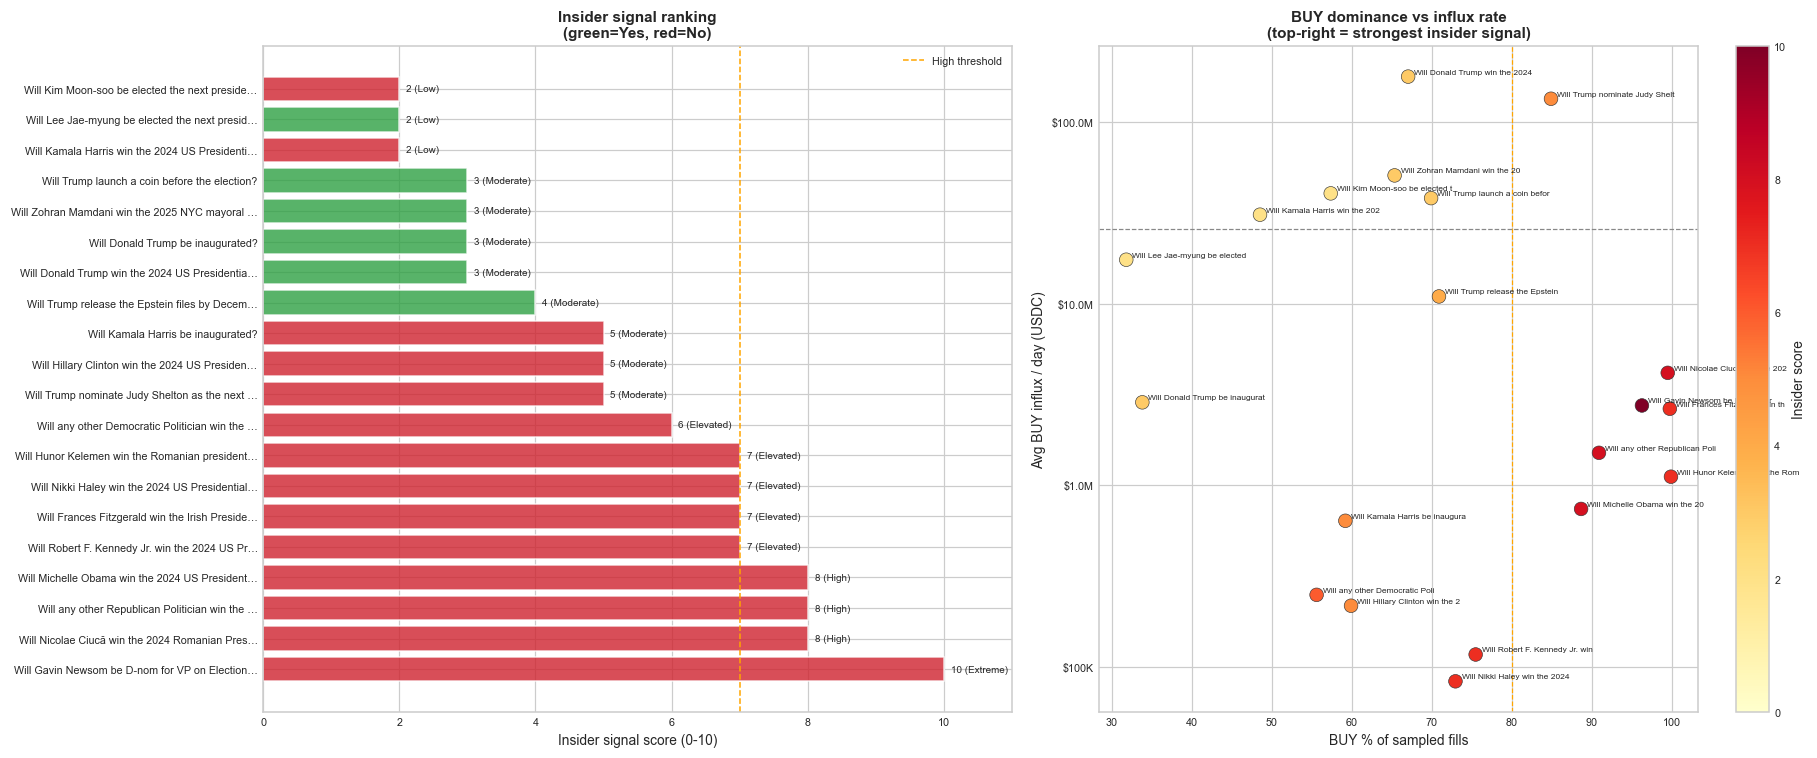

In [5]:
signals_df = pl.DataFrame(all_signals).sort('score', descending=True)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# Horizontal bar — insider scores
ax = axes[0]
labels = [r['question'][:45] + '…' if len(r['question']) > 45 else r['question']
          for r in signals_df.iter_rows(named=True)]
scores = signals_df['score'].to_list()
res    = signals_df['resolution'].to_list()
bar_colors = ['#2ea043' if r == 'Yes' else '#cf222e' for r in res]
y = np.arange(len(labels))
ax.barh(y, scores, color=bar_colors, alpha=0.8, edgecolor='white')
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel('Insider signal score (0-10)')
ax.set_title('Insider signal ranking\n(green=Yes, red=No)', fontweight='bold')
ax.axvline(7, color='orange', linewidth=1.0, linestyle='--', label='High threshold')
ax.legend(fontsize=7)
ax.set_xlim(0, 11)
for i, (s, lbl) in enumerate(zip(scores, [r['signal'] for r in signals_df.iter_rows(named=True)])):
    ax.text(s + 0.1, i, f'{s} ({lbl})', va='center', fontsize=6.5)

# Scatter — BUY% vs avg influx
ax2 = axes[1]
buy_pcts  = signals_df['buy_pct'].to_list()
influxes  = signals_df['avg_influx_per_day'].to_list()
mkt_names = [r['question'][:30] for r in signals_df.iter_rows(named=True)]
sc_colors = ['#2ea043' if r == 'Yes' else '#cf222e' for r in res]

sc = ax2.scatter(buy_pcts, influxes, c=scores, cmap='YlOrRd', s=80, zorder=3,
                 vmin=0, vmax=10, edgecolors='#333', linewidths=0.4)
plt.colorbar(sc, ax=ax2, label='Insider score')
for i, (bx, iy, nm) in enumerate(zip(buy_pcts, influxes, mkt_names)):
    ax2.annotate(nm, (bx, iy), fontsize=5.5, xytext=(4, 2), textcoords='offset points')
ax2.axvline(80, color='orange', linewidth=0.8, linestyle='--')
ax2.axhline(np.mean([i for i in influxes if i > 0]), color='#888', linewidth=0.8, linestyle='--')
ax2.set_xlabel('BUY % of sampled fills')
ax2.set_ylabel('Avg BUY influx / day (USDC)')
ax2.set_yscale('log')
ax2.yaxis.set_major_formatter(fmt_usdc)
ax2.set_title('BUY dominance vs influx rate\n(top-right = strongest insider signal)', fontweight='bold')

plt.tight_layout()
plt.show()

In [6]:
print('\nFull ranking table:\n')
print(f'{"Rank":<5} {"Score":<6} {"Signal":<12} {"Res":<5} {"BUY%":<7} {"AvgInflux/d":<14} {"MaxBet":<14} {"Question"}')
print('-' * 120)
for i, r in enumerate(signals_df.iter_rows(named=True), 1):
    print(f'{i:<5} {r["score"]:<6} {r["signal"]:<12} {r["resolution"]:<5} '
          f'{r["buy_pct"]:>5.1f}%  '
          f'${r["avg_influx_per_day"]/1e3:>9,.0f}K  '
          f'${r["max_bet"]:>10,.0f}  '
          f'{r["question"][:60]}')


Full ranking table:

Rank  Score  Signal       Res   BUY%    AvgInflux/d    MaxBet         Question
------------------------------------------------------------------------------------------------------------------------
1     10     Extreme      No     96.3%  $    2,751K  $   661,584  Will Gavin Newsom be D-nom for VP on Election Day?
2     8      High         No     99.5%  $    4,159K  $    45,820  Will Nicolae Ciucă win the 2024 Romanian Presidential electi
3     8      High         No     90.9%  $    1,510K  $ 1,870,954  Will any other Republican Politician win the 2024 US Preside
4     8      High         No     88.7%  $      741K  $ 1,633,296  Will Michelle Obama win the 2024 US Presidential Election?
5     7      Elevated     No     75.5%  $      117K  $   747,340  Will Robert F. Kennedy Jr. win the 2024 US Presidential Elec
6     7      Elevated     No     99.8%  $    2,639K  $   105,070  Will Frances Fitzgerald win the Irish Presidential Election?
7     7      Elevated     No